# TM-RugPull dataset initial analysis

## Data collection

In [1]:
 # Loading data from .xlsx file

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

file = '../data/TM-RugPull_original.xlsx'

data = pd.read_excel(file)

# Remove a space in the end of some column names
data.columns = data.columns.str.strip()

print(data.shape)

pd.set_option('display.max_columns', None)

data.head(5)

(1000, 27)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,9.537265e-03,4.929203e-02,166600000000100,HVT,44,POSA,sourse code,CODE,https://thehyperverse.net/index.html,https://twitter.com/HyperVerse6,scam,2022-01-27,2023-07-14,148,148,29,8,74,47
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2.487228e+03,4.503032e+07,34403.74594,BEP-20 TOKEN*,1,POSA,sourse code,CODE,https://web.archive.org/web/20230603123631/htt...,NaN,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,8.901714e+14,6.695544e+17,10000000000,Flare,53,POSA,sourse code,CODE,https://pipeflare.io/,https://x.com/MetaFlareToken,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,2.457331e+10,8.139816e+14,61634066.59803,SAFUU,2,POSA,sourse code,CODE,https://safuu.com/,https://x.com/safuuxofficial,scam,2022-02-03,2022-08-13,327,323,0,0,5,4
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4.252172e+06,1.410127e+05,"42,896,736.739367",SCT,52,POSA,sourse code,CODE,https://supercells.jp/en/,https://x.com/scttoken,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594


In [2]:
# Check the balance between classes in the whole dataset
# Source: https://note.nkmk.me/en/python-pandas-value-counts/#value_counts

class_counts = data['class'].value_counts()
class_percent = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts.to_string(), "\nIn %:", class_percent.to_string())

Counts: class
scam      599
normal    401 
In %: class
scam      59.9
normal    40.1


In [3]:
# Check general info about data

print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Project Title                                          1000 non-null   object        
 1   MaxPrice (Quarter 1)                                   1000 non-null   float64       
 2   MaxPrice (Quarter 2)                                   1000 non-null   float64       
 3   MaxPrice (Quarter 3)                                   1000 non-null   float64       
 4   MaxPrice (Quarter 4)                                   1000 non-null   float64       
 5   Blockchain                                             1000 non-null   object        
 6   the number of Transactions                             1000 non-null   object        
 7   Number of holders                               

In [4]:
# Analysis of blockchain distribution in data

blockchain_distribution = data['Blockchain'].value_counts(normalize=True) * 100
print(blockchain_distribution.to_string())

Blockchain
ETH        63.3
BSC        32.1
POLYGON     2.4
ARBI        1.2
FANTOM      0.4
CRONO       0.2
BASE        0.2
FTM         0.1
SNOW        0.1


In [5]:
# Analyse scam rate per chain

scam_rate_per_chain = (
    data.groupby('Blockchain')['class']
        .apply(lambda s: (s == 'scam').mean())
        .sort_values(ascending=False)
)

scam_rate_percents = (scam_rate_per_chain * 100)

print(scam_rate_percents.to_string())

Blockchain
BASE       100.000000
CRONO      100.000000
FANTOM     100.000000
FTM        100.000000
BSC         75.077882
POLYGON     62.500000
ARBI        58.333333
ETH         51.658768
SNOW         0.000000


##### As far as FANTOM, CRONO, BASE and SNOW blockchains have very few samples (less than 10) and are biased (only scam tokens for BASE, CRONO and FANTOM and only normal samples for SNOW), these blockchains will be removed from the dataset.

In [6]:
# Drop blockchains with number of samples less than 1%

min_samples = 1.0
chains_to_keep = blockchain_distribution[blockchain_distribution >= min_samples].index
chains_dropped = blockchain_distribution[blockchain_distribution < min_samples]

print("Blockchains to keep:")
print(list(chains_to_keep))

print("\nDropped blockchains:")
print(chains_dropped.to_string())

data = data[data['Blockchain'].isin(chains_to_keep)].copy()

Blockchains to keep:
['ETH', 'BSC', 'POLYGON', 'ARBI']

Dropped blockchains:
Blockchain
FANTOM    0.4
CRONO     0.2
BASE      0.2
FTM       0.1
SNOW      0.1


In [7]:
# Dataset after dropping blockchains with small number of samples

print(data.shape)
data.head(5)

(990, 27)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,9.537265e-03,4.929203e-02,166600000000100,HVT,44,POSA,sourse code,CODE,https://thehyperverse.net/index.html,https://twitter.com/HyperVerse6,scam,2022-01-27,2023-07-14,148,148,29,8,74,47
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2.487228e+03,4.503032e+07,34403.74594,BEP-20 TOKEN*,1,POSA,sourse code,CODE,https://web.archive.org/web/20230603123631/htt...,NaN,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,8.901714e+14,6.695544e+17,10000000000,Flare,53,POSA,sourse code,CODE,https://pipeflare.io/,https://x.com/MetaFlareToken,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,2.457331e+10,8.139816e+14,61634066.59803,SAFUU,2,POSA,sourse code,CODE,https://safuu.com/,https://x.com/safuuxofficial,scam,2022-02-03,2022-08-13,327,323,0,0,5,4
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4.252172e+06,1.410127e+05,"42,896,736.739367",SCT,52,POSA,sourse code,CODE,https://supercells.jp/en/,https://x.com/scttoken,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594


In [8]:
# Display blockchain distribution after dropping blockchains with small number of samples

blockchain_distribution = data['Blockchain'].value_counts(normalize=True) * 100
print(blockchain_distribution.to_string())

Blockchain
ETH        63.939394
BSC        32.424242
POLYGON     2.424242
ARBI        1.212121


##### Create a train set and a test set

In [9]:
# Create a test set and a train set from raw data to avoid data leakage.
# A split is temporal, preserving project period balance (based on start date), so that both old and new projects are presented in each split.
# Train set size is about 67% and test set size is about 33% from the whole data set.

# Reference: https://stackoverflow.com/questions/45516424/sklearn-train-test-split-on-pandas-stratify-by-multiple-columns

from sklearn.model_selection import train_test_split

# Convert project starting date to datetime and extract year
data['project starting date'] = pd.to_datetime(data['project starting date'], errors='coerce')
data['project starting year'] = data['project starting date'].dt.year

# Group years into broader periods
def assign_project_period(year):
    if year < 2021:
        return 'before_2021'
    elif year in [2021, 2022, 2023]:
        return str(year)
    elif year in [2024, 2025]:
        return '2024_2025'
    else:
        return 'unknown'

data['project period'] = data['project starting year'].apply(assign_project_period)

# Define seed
seed = 7

# Combined stratification label for the full dataset (class and project period)
combined_labels = data['class'].astype(str) + '|' + data['project period'].astype(str)

# Split the data on train set and test set
train_set, test_set = train_test_split(data, test_size=0.33, random_state=seed, stratify=combined_labels)

# Output the shapes to verify the splits
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)

# Create a list of sets to perform further feature engineering on all subsets of data
data_sets = [train_set, test_set]

train_set.head(5)

Training set shape: (663, 29)
Test set shape: (327, 29)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2),project starting year,project period
949,Aurora (AURORA),34.000000,12.400000,5.780000,2.000000,ETH,130689,6727,1.072607e+14,2.309422e+17,1000000000,AURORA,9.1,POS,sourse code,CODE,https://aurora.dev/,https://twitter.com/auroraisnear,normal,2021-12-04,2022-12-10,1890,994,42,6,745,437,2021,2021
335,ShipChain SHIP (SHIP),0.199638,0.010277,0.030425,0.032866,ETH,54323,18323,2.457802e+12,4.323626e+15,500000000,SHIP,0.09992,POS,sourse code,CODE,https://shipchain.io/,https://twitter.com/shipchain,scam,2018-03-18,2021-06-20,166,42,114,42,379,216,2018,before_2021
487,Robotina token (ROX),0.048000,0.091900,0.074000,0.041500,ETH,26448,5678,6.689802e+11,1.068798e+14,331614076.921422,ROX,0.0305,POS,sourse code,CODE,https://robotinarox.io/,https://twitter.com/robotinarox_io,scam,2018-09-29,2020-09-30,4,3,40,42,5,3,2018,before_2021
710,Compound Ether (cETH),88.000000,74.000000,75.000000,66.000000,ETH,"416,850",70956,6.841864e+06,1.873493e+10,2863050.33621,cETH,41,POS,sourse code,CODE,https://compound.finance/,https://twitter.com/compoundfinance,normal,2021-04-10,2024-11-23,7,4,28,10,349,65,2021,2021
685,Cryptocurrency Top 10 Tokens Index (CC10),79.000000,108.000000,73.000000,4489.000000,ETH,24654,908,1.199781e+14,3.229262e+14,2985310606.6358,CC10,48,POS,sourse code,CODE,https://indexed.finance/,https://twitter.com/ndxfi,normal,2021-01-23,2021-12-02,0,0,214000,123000,261,139,2021,2021


In [10]:
# Verify that there is no overlap between sets, no data leak at this stage
print("Overlap between train and test:", np.intersect1d(train_set.index, test_set.index).size)

Overlap between train and test: 0


In [11]:
# Combined stratification labels (class and project period) for cross-validation to make it also temporal

combined_labels_train = train_set['class'].astype(str) + '|' + train_set['project period'].astype(str)
combined_labels_test = test_set['class'].astype(str) + '|' + test_set['project period'].astype(str)

In [12]:
# Delete columns that are not useful for further analysis

for data_set in data_sets:
    data_set.drop(columns=['Project Title', 'Sign', 'website', 'x profile', 'Smart Contract (online)', 'smart Contract (offline)', 'project starting date', 'project end date', 'project starting year', 'project period'], inplace=True)

# Check the result on train set
train_set.head(10)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
949,3.400000e+01,1.240000e+01,5.780000e+00,2.000000e+00,ETH,130689,6727,1.072607e+14,2.309422e+17,1000000000,9.1,POS,normal,1890,994,42,6,745,437
335,1.996380e-01,1.027700e-02,3.042500e-02,3.286600e-02,ETH,54323,18323,2.457802e+12,4.323626e+15,500000000,0.09992,POS,scam,166,42,114,42,379,216
487,4.800000e-02,9.190000e-02,7.400000e-02,4.150000e-02,ETH,26448,5678,6.689802e+11,1.068798e+14,331614076.921422,0.0305,POS,scam,4,3,40,42,5,3
710,8.800000e+01,7.400000e+01,7.500000e+01,6.600000e+01,ETH,"416,850",70956,6.841864e+06,1.873493e+10,2863050.33621,41,POS,normal,7,4,28,10,349,65
685,7.900000e+01,1.080000e+02,7.300000e+01,4.489000e+03,ETH,24654,908,1.199781e+14,3.229262e+14,2985310606.6358,48,POS,normal,0,0,214000,123000,261,139
107,1.480000e-07,1.588000e-07,1.271000e-07,9.989000e-09,BSC,847443,19020,3.599112e+15,2.245004e+19,9999999997,0.0,POSA,scam,0,0,2,1,374,849
690,4.990000e+02,1.709000e+01,2.963000e+01,2.683000e+01,ETH,6892613,7143,2.599106e+04,7.051642e+06,52631.030113,137.84,POS,normal,0,0,1,0,10,7
966,4.800000e+00,3.400000e-01,1.020000e-01,9.400000e-02,ETH,199703,17070,2.012793e+13,2.958962e+16,1850000000,4.8,POS,normal,201,97,101000,43300,0,0
298,1.065000e-07,5.207000e-08,1.649680e+05,1.522440e+05,ETH,4345,339,1.127190e+08,1.498484e+01,1000000000000,0.0,POS,scam,2,2,1,1,7,1
489,2.450000e-02,3.290000e-02,1.114000e-01,9.360000e-02,ETH,9298,1595,6.357819e+12,8.456319e+14,225000000,0.0257,POS,scam,299,108,110,9,55,7


## Raw data analysis

##### Performed first on raw data to get overall idea of what the dataset contains.
##### All further exploratory operations except checking general info should be done only on the train set to avoid data leakage.
##### Analysis of skew and correlation is performed only on numeric features first. Categorial features are initially analysed separately, then encoded during pre-processing.

In [13]:
# Encode class label

from sklearn.preprocessing import LabelEncoder

for data_set in data_sets:
    le = LabelEncoder()
    data_set['class'] = data_set['class'].map({'normal': 0, 'scam': 1})

train_set

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
949,34.000000,12.400000,5.780000,2.000000,ETH,130689,6727,1.072607e+14,2.309422e+17,1000000000,9.1,POS,0,1890,994,42,6,745,437
335,0.199638,0.010277,0.030425,0.032866,ETH,54323,18323,2.457802e+12,4.323626e+15,500000000,0.09992,POS,1,166,42,114,42,379,216
487,0.048000,0.091900,0.074000,0.041500,ETH,26448,5678,6.689802e+11,1.068798e+14,331614076.921422,0.0305,POS,1,4,3,40,42,5,3
710,88.000000,74.000000,75.000000,66.000000,ETH,"416,850",70956,6.841864e+06,1.873493e+10,2863050.33621,41,POS,0,7,4,28,10,349,65
685,79.000000,108.000000,73.000000,4489.000000,ETH,24654,908,1.199781e+14,3.229262e+14,2985310606.6358,48,POS,0,0,0,214000,123000,261,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,4.430000,2.140000,0.603000,0.870000,BSC,4715912,177817,6.750565e+11,6.191921e+15,500000000,1.744,POSA,0,490,177,96,9,2870,1840
632,1.206000,1.040000,1.017000,1.084000,ETH,"262,543,621",6313774,1.624152e+15,9.777368e+18,60939188189.669403,1.206,POS,0,1310,3,493,11,1330,42
273,0.000803,0.000019,0.000027,0.000038,ETH,11520,911,6.245692e+16,9.148279e+18,10000000000,0.000803,POS,1,4,3,1,0,47,47
36,0.531024,0.597108,0.508997,0.384172,BSC,90922,788,9.943130e+10,6.183796e+12,21000000,0.253841,POSA,1,1920,703,0,0,0,0


In [14]:
# Check the data description

description = train_set.describe()
description

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Total Variance,Variance of holders with more than 1% tokens,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
count,6.630000e+02,6.630000e+02,6.630000e+02,6.630000e+02,6.630000e+02,6.630000e+02,663.000000,6.630000e+02,663.000000,663.000000,663.000000
mean,5.184395e+08,6.808764e+06,5.787155e+06,1.683152e+08,9.796723e+113,4.814985e+114,0.595777,2.672280e+04,1250.903469,2267.791855,732.746606
std,1.334917e+10,1.753016e+08,1.489816e+08,4.333884e+09,2.522537e+115,1.239800e+116,0.491112,6.369707e+05,10630.597807,15904.211634,4805.922405
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.239937e-18,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1.277000e-03,8.984150e-04,5.200900e-04,4.867500e-04,1.663645e+11,3.494565e+13,0.000000,3.000000e+00,2.000000,3.000000,2.000000
50%,1.480000e-01,7.800000e-02,5.379580e-02,4.700000e-02,3.984736e+13,6.191921e+15,1.000000,5.100000e+01,9.000000,47.000000,18.000000
75%,1.925000e+00,1.103500e+00,9.330515e-01,8.969115e-01,1.682685e+17,8.328021e+18,1.000000,3.760000e+02,214.000000,344.000000,137.500000
max,3.437249e+11,4.513804e+09,3.836097e+09,1.115922e+11,6.495228e+116,3.192335e+117,1.000000,1.640000e+07,230000.000000,240000.000000,94000.000000


In [15]:
# Check the balance between classes in the training set

class_counts_train = data['class'].value_counts()
class_percent_train = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts_train.to_string(), "\nIn %:", class_percent_train.to_string())

Counts: class
scam      590
normal    400 
In %: class
scam      59.59596
normal    40.40404


In [16]:
# Check for missing values

print("\nMissing values:\n", train_set.isnull().sum())


Missing values:
 MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Number of holders                                        0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
first deposits                                           0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (du

In [17]:
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
Blockchain                                                object
the number of Transactions                                object
Number of holders                                         object
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                             object
first deposits                                            object
Blockchain Type                                           object
class                                                      int64
Google results for project title (first day)               int64
Google results for project title (project duration/2)      int64
Google results for projec

In [18]:
# Transfer all data to numeric values

# Columns with object datatype
cols_to_clean = [
    'the number of Transactions',
    'Number of holders',
    'Token balance',
    'first deposits',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)'
]

# Apply to all data splits
data_sets = [train_set, test_set]

for i, data_set in enumerate(data_sets):
    for col in cols_to_clean:
        data_sets[i][col] = pd.to_numeric(
            data_set[col].astype(str)
                   .str.replace('\xa0', '', regex=False)        # Remove non-breaking whitespaces
                   .str.replace(',', '', regex=False)           # Strip comas separating numeric values
                   .str.strip(),                                # Remove surrounding whitespaces
            errors='coerce'                                     # If cannot parse, put NaN
        )

train_set, test_set = data_sets

# Verify the result
print("Datatypes:\n", train_set[cols_to_clean].dtypes)
print("\nMissing values:\n", train_set[cols_to_clean].isnull().sum())
print("\nColumns description\n", train_set[cols_to_clean].describe())

Datatypes:
 the number of Transactions                         float64
Number of holders                                    int64
Token balance                                      float64
first deposits                                     float64
Google results for project website (first day)     float64
Google results for project website (duration/2)    float64
dtype: object

Missing values:
 the number of Transactions                         0
Number of holders                                  0
Token balance                                      1
first deposits                                     0
Google results for project website (first day)     2
Google results for project website (duration/2)    2
dtype: int64

Columns description
        the number of Transactions  Number of holders  Token balance  \
count                6.630000e+02       6.630000e+02   6.620000e+02   
mean                 1.449411e+06       6.931306e+06   1.749125e+56   
std                  1.443167e+07   

In [19]:
# Some extreme values (like 10ˆ59) result in overflow warnings when computing skew, and NaN values for 'Total Variance'
# and 'Variance of holders with more than 1% tokens'.
# These values were capped at the 99.5 percentile estimated from the training data and applied to all datasets.

# Reference: S. Galli, Python Feature Engineering Cookbook: Over 70 recipes for creating, engineering, and transforming features to build machine learning models, Packt Publishing, 2022.

cols_to_clip = [
    'Total Variance',
    'Variance of holders with more than 1% tokens'
]

# Clip at 99.5% quantile (computed on train_set only)
upper_q = 0.995

for col in cols_to_clip:
    upper = train_set[col].quantile(upper_q)
    for data_set in data_sets:
        data_set[col] = data_set[col].clip(upper=upper)

In [20]:
# Check for skew for numeric columns

numeric_cols = train_set.select_dtypes(include=['number']).columns
skew = train_set[numeric_cols].skew()

skew

MaxPrice (Quarter 1)                                     25.748786
MaxPrice (Quarter 2)                                     25.748786
MaxPrice (Quarter 3)                                     25.748786
MaxPrice (Quarter 4)                                     25.748786
the number of Transactions                               16.194656
Number of holders                                        25.748698
Total Variance                                           12.786536
Variance of holders with more than 1% tokens             12.785800
Token balance                                            25.729361
first deposits                                           22.513843
class                                                    -0.391221
Google results for project title (first day)             25.733697
Google results for project title (project duration/2)    17.154789
Google results for project website (first day)           19.764636
Google results for project website (duration/2)          13.18

### Visualisation

##### Based on CSM010-2024-APR, Topic 2, Lab.2.15. Analysing data

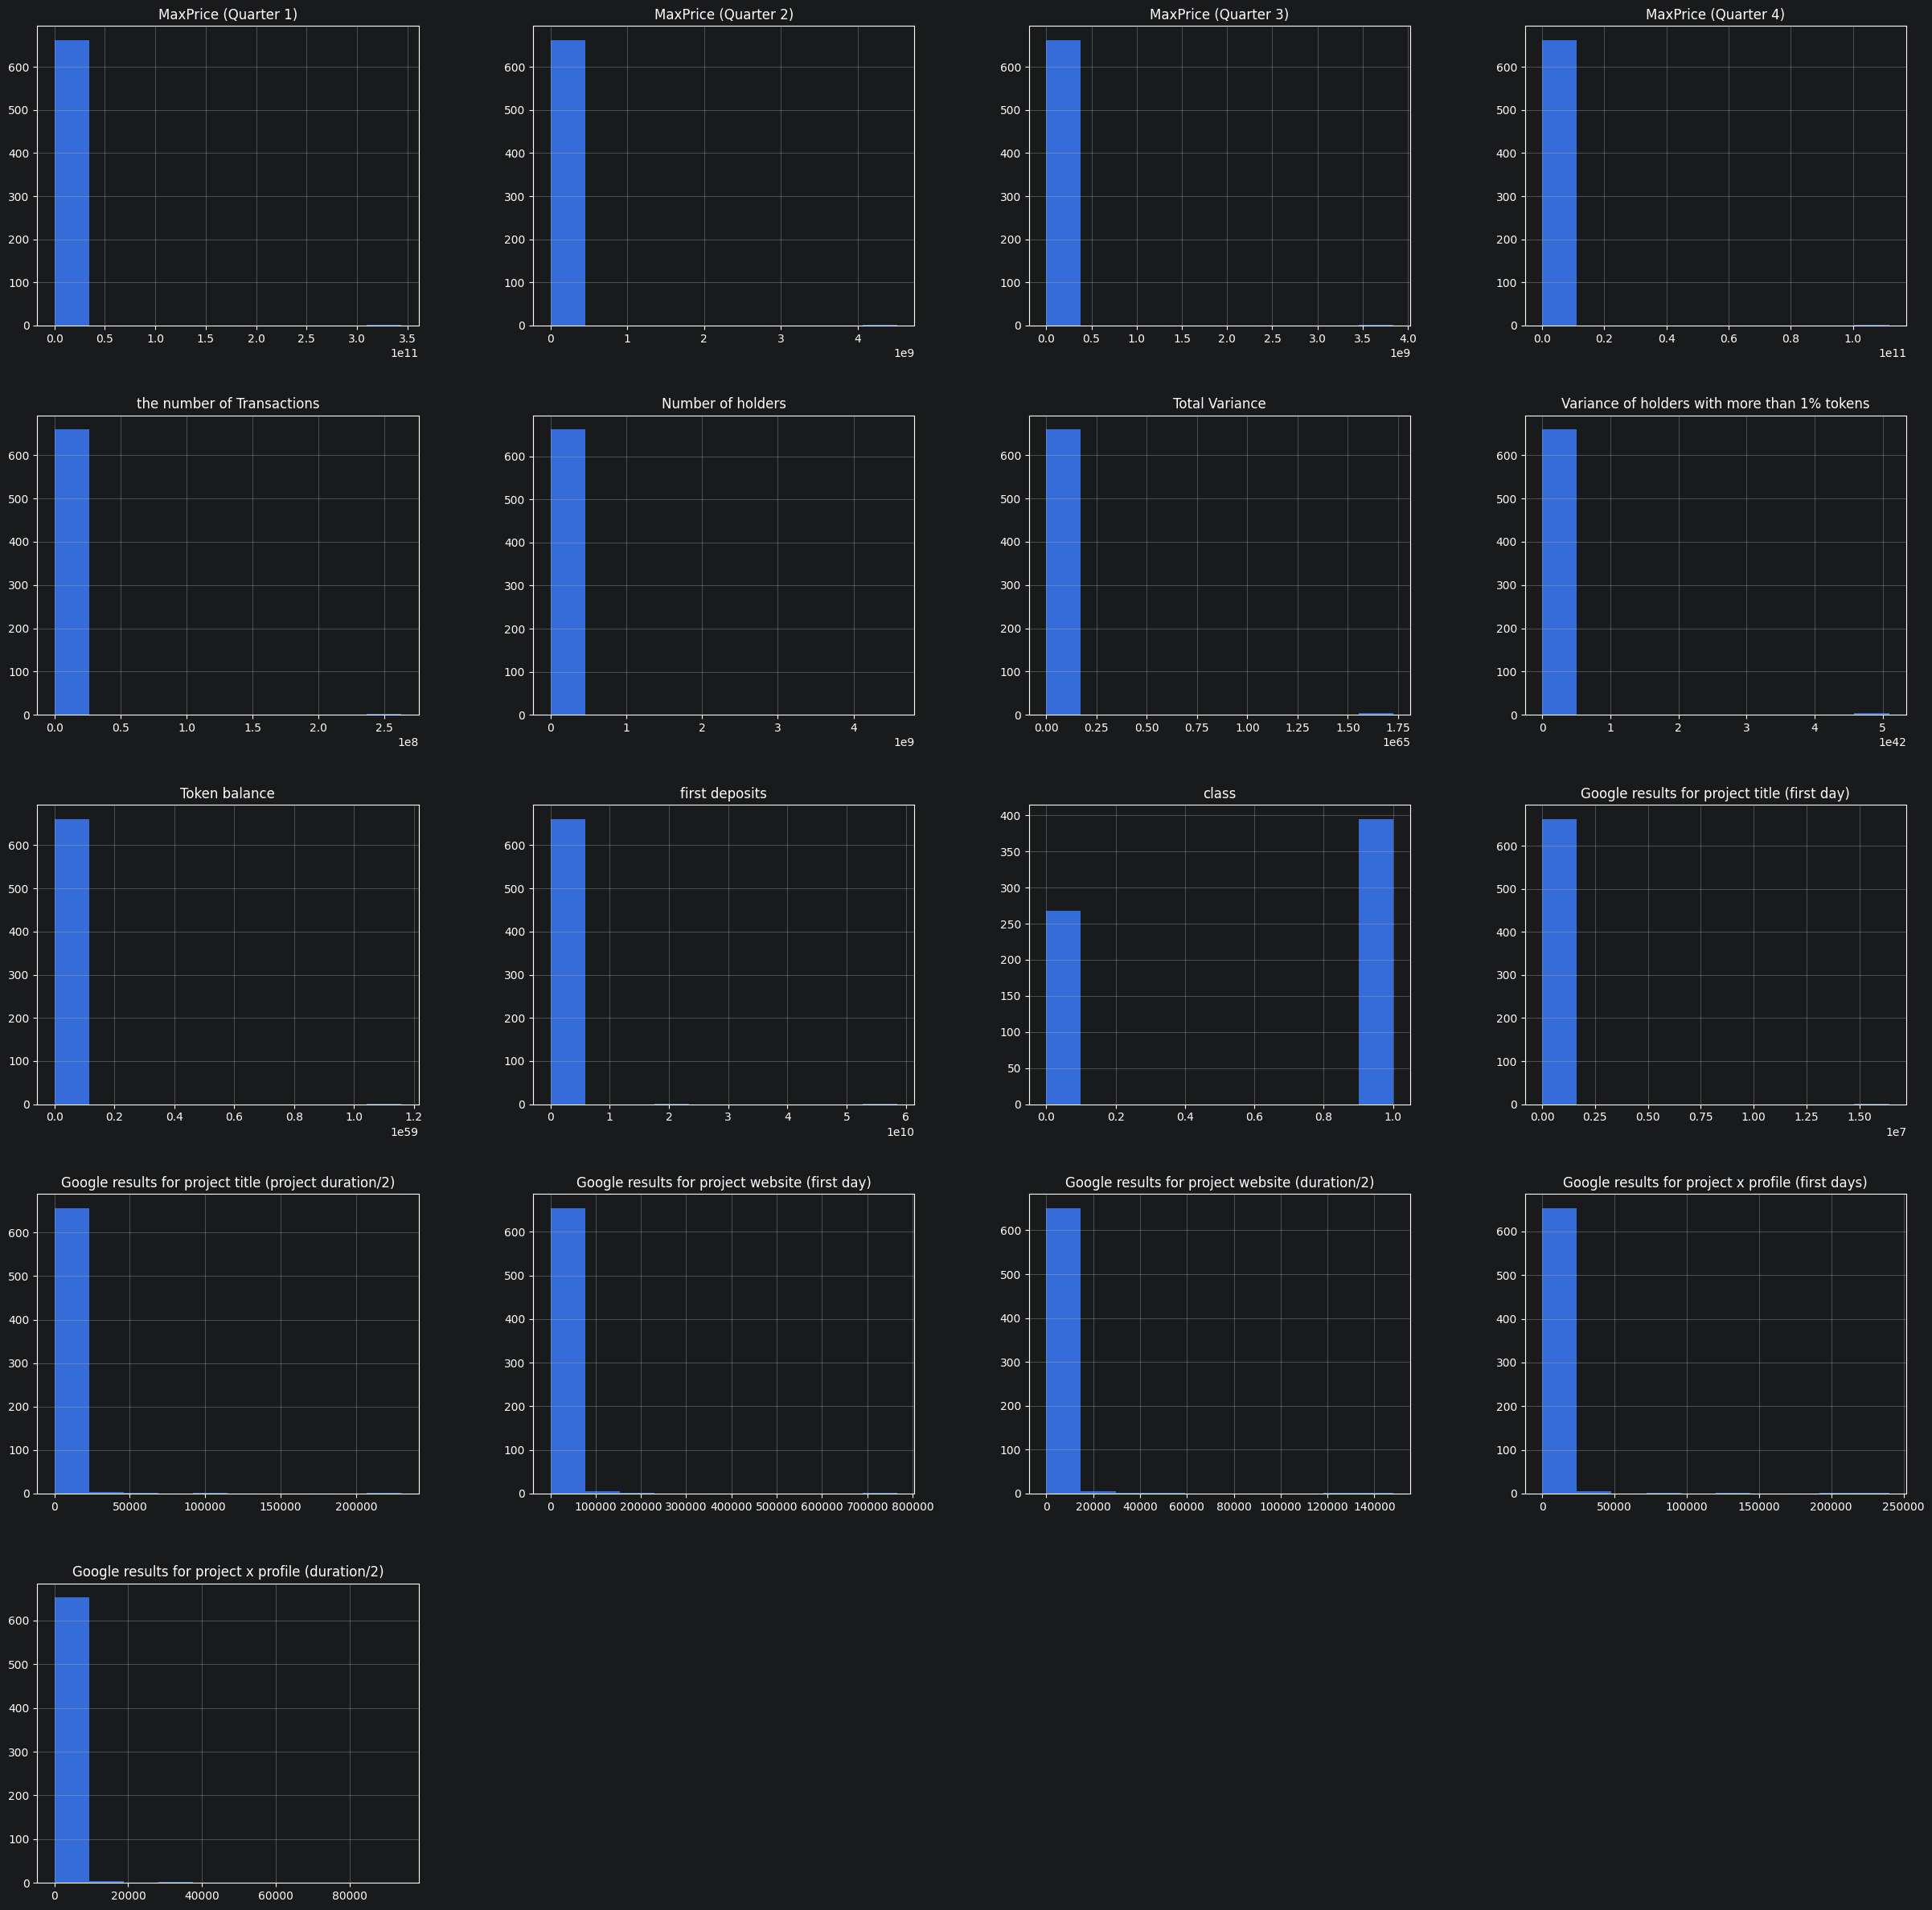

In [21]:
# Histograms

train_set.hist(figsize=[30, 30])
pyplot.show()

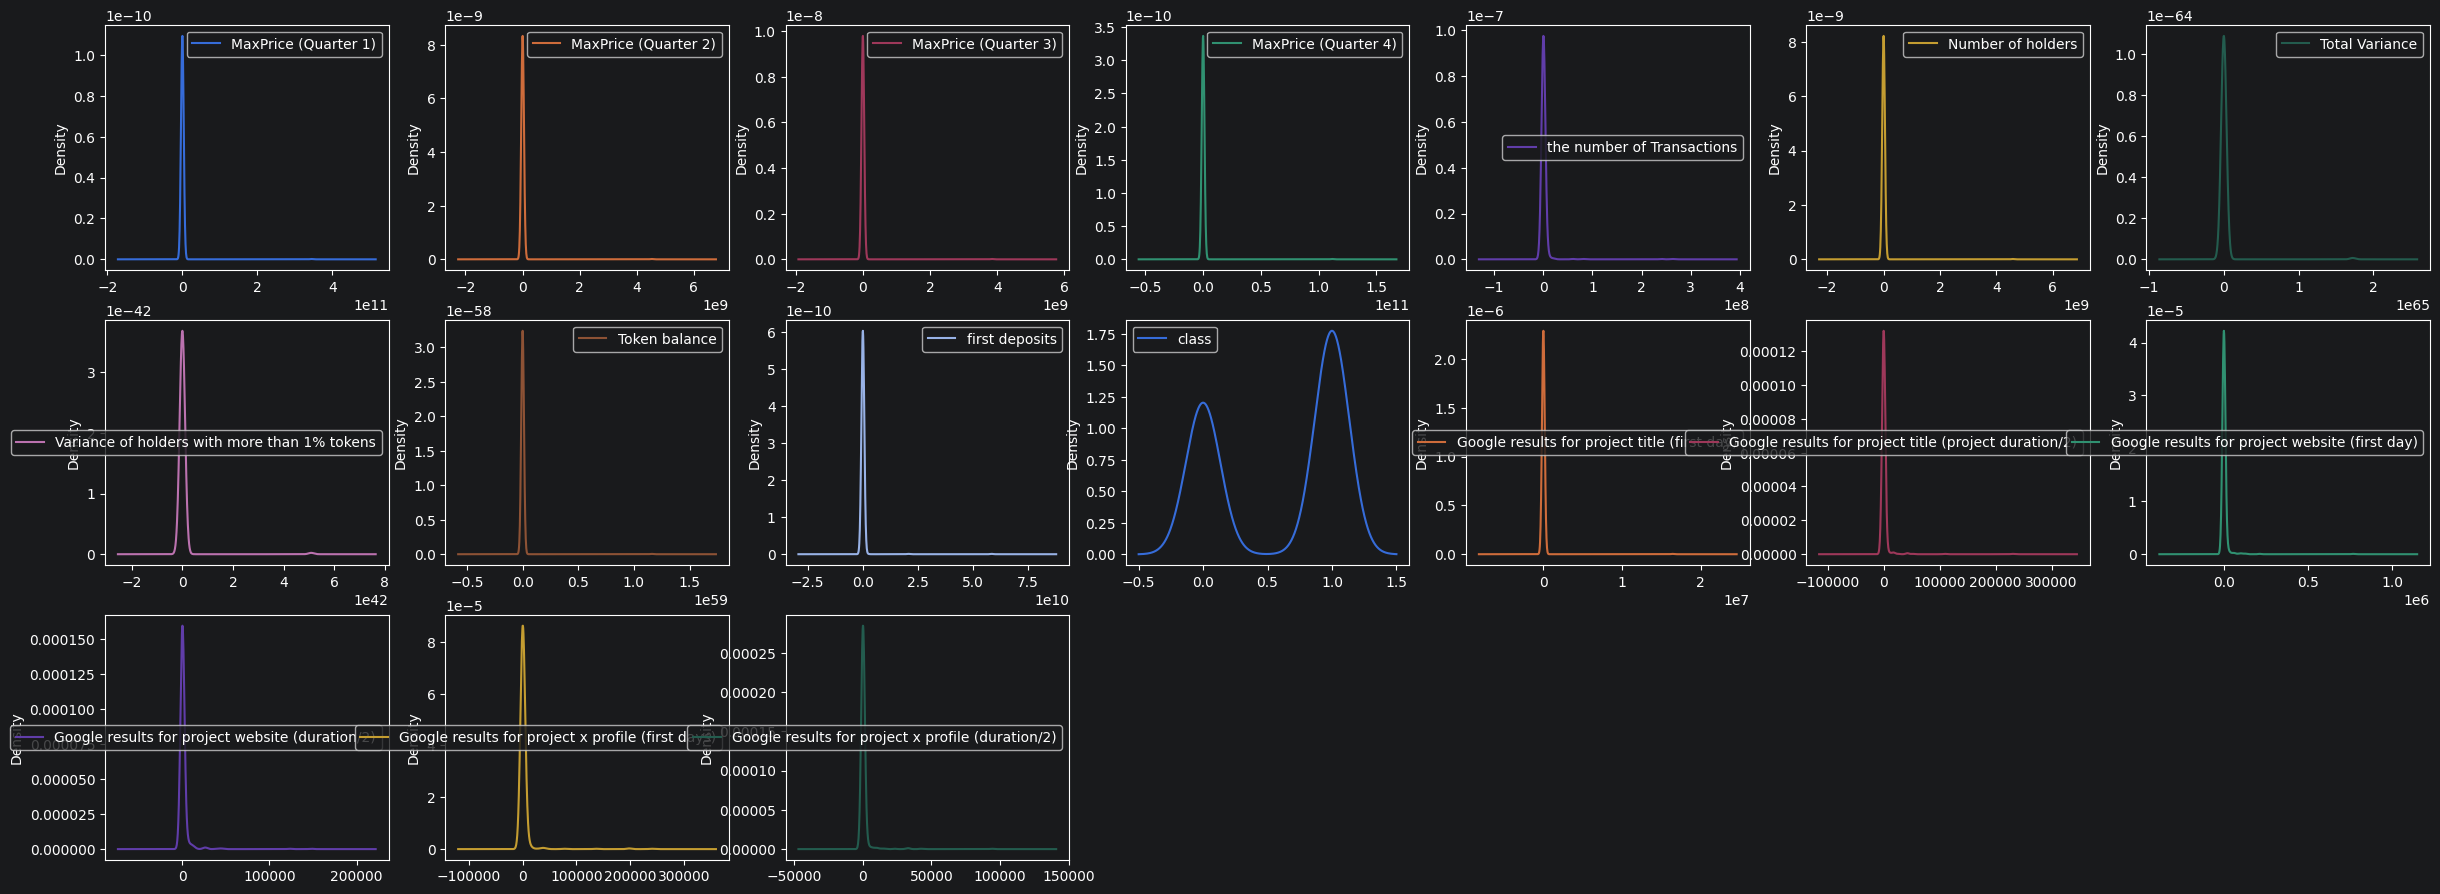

In [22]:
# Density plots

train_set.plot(kind='density', subplots=True, layout=(8,7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

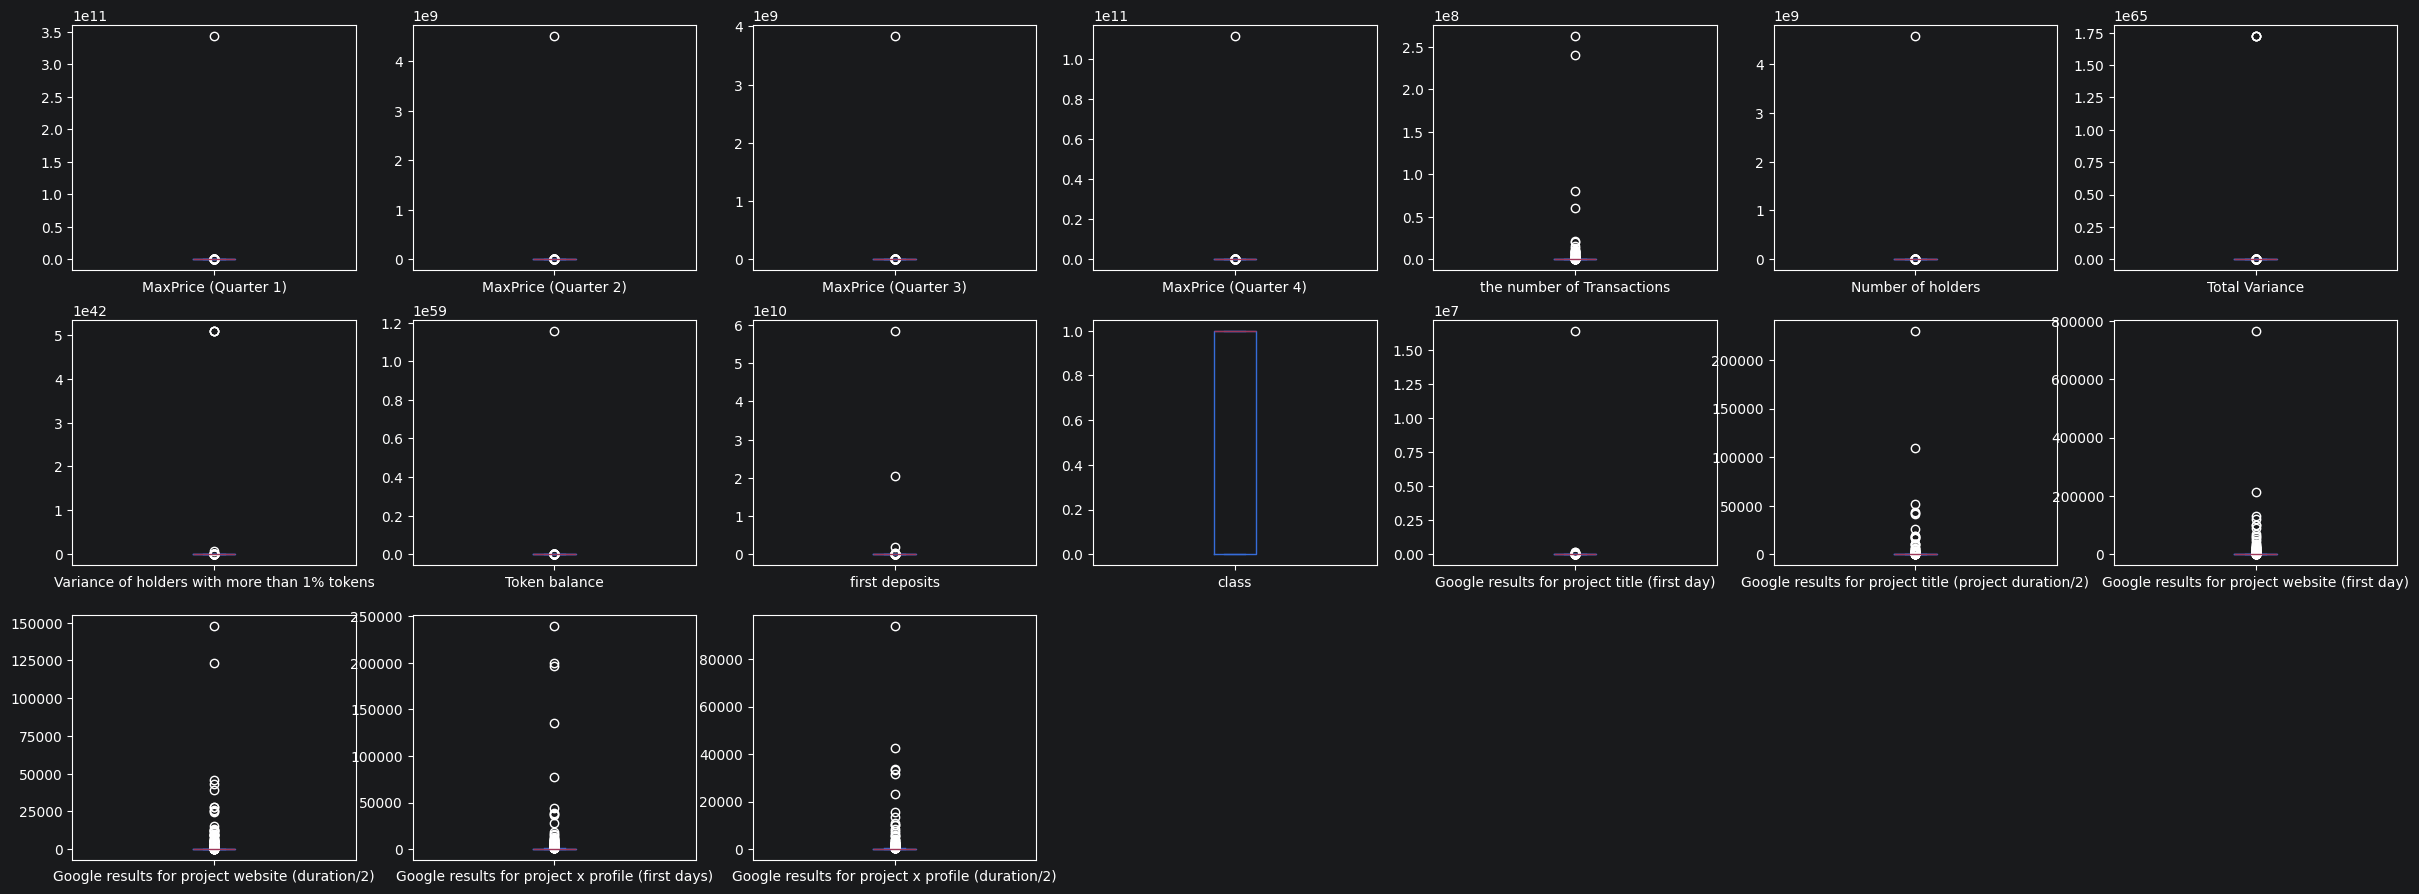

In [23]:
# Box and Whisker Plots

train_set.plot(kind='box', subplots=True, layout=(8,7), sharex=False, sharey=False,figsize=[30, 30])
pyplot.show()

##### Data is extremely skewed and there are extreme outliers, thus, data requires pre-processing.

In [24]:
# Search for correlations of numeric features

correlations = train_set[numeric_cols].corr(method='pearson')

correlations

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
MaxPrice (Quarter 1),1.000000,1.000000,1.000000,1.000000,-0.003776,-0.001517,-0.003028,-0.003040,-0.001513,0.942956,0.032014,-0.001632,-0.004577,-0.004469,-0.006095,0.021845,0.042305
MaxPrice (Quarter 2),1.000000,1.000000,1.000000,1.000000,-0.003775,-0.001517,-0.003028,-0.003040,-0.001513,0.942956,0.032015,-0.001632,-0.004577,-0.004469,-0.006095,0.021844,0.042305
MaxPrice (Quarter 3),1.000000,1.000000,1.000000,1.000000,-0.003773,-0.001518,-0.003029,-0.003040,-0.001513,0.942956,0.032018,-0.001632,-0.004578,-0.004470,-0.006096,0.021844,0.042304
MaxPrice (Quarter 4),1.000000,1.000000,1.000000,1.000000,-0.003776,-0.001517,-0.003028,-0.003040,-0.001513,0.942956,0.032014,-0.001632,-0.004577,-0.004469,-0.006095,0.021845,0.042305
the number of Transactions,-0.003776,-0.003775,-0.003773,-0.003776,1.000000,-0.000921,-0.007819,-0.007853,-0.003908,-0.004910,-0.115357,-0.003956,-0.009253,0.001611,0.006178,0.008826,0.002254
Number of holders,-0.001517,-0.001517,-0.001518,-0.001517,-0.000921,1.000000,-0.003043,-0.003055,-0.001520,-0.002001,-0.047381,-0.001637,-0.004479,-0.004474,-0.006084,-0.005498,-0.005837
Total Variance,-0.003028,-0.003028,-0.003029,-0.003028,-0.007819,-0.003043,1.000000,0.496944,-0.003033,-0.003993,0.064174,-0.003262,-0.008936,-0.008852,-0.011987,-0.011007,-0.011624
Variance of holders with more than 1% tokens,-0.003040,-0.003040,-0.003040,-0.003040,-0.007853,-0.003055,0.496944,1.000000,-0.003044,-0.004008,0.064399,-0.003278,-0.008979,-0.008706,-0.011382,-0.010965,-0.011504
Token balance,-0.001513,-0.001513,-0.001513,-0.001513,-0.003908,-0.001520,-0.003033,-0.003044,1.000000,-0.001995,0.032079,-0.001630,-0.004397,-0.004476,-0.006104,-0.005471,-0.005664
first deposits,0.942956,0.942956,0.942956,0.942956,-0.004910,-0.002001,-0.003993,-0.004008,-0.001995,1.000000,0.042211,-0.002113,-0.005260,-0.005816,-0.007965,0.019160,0.039065


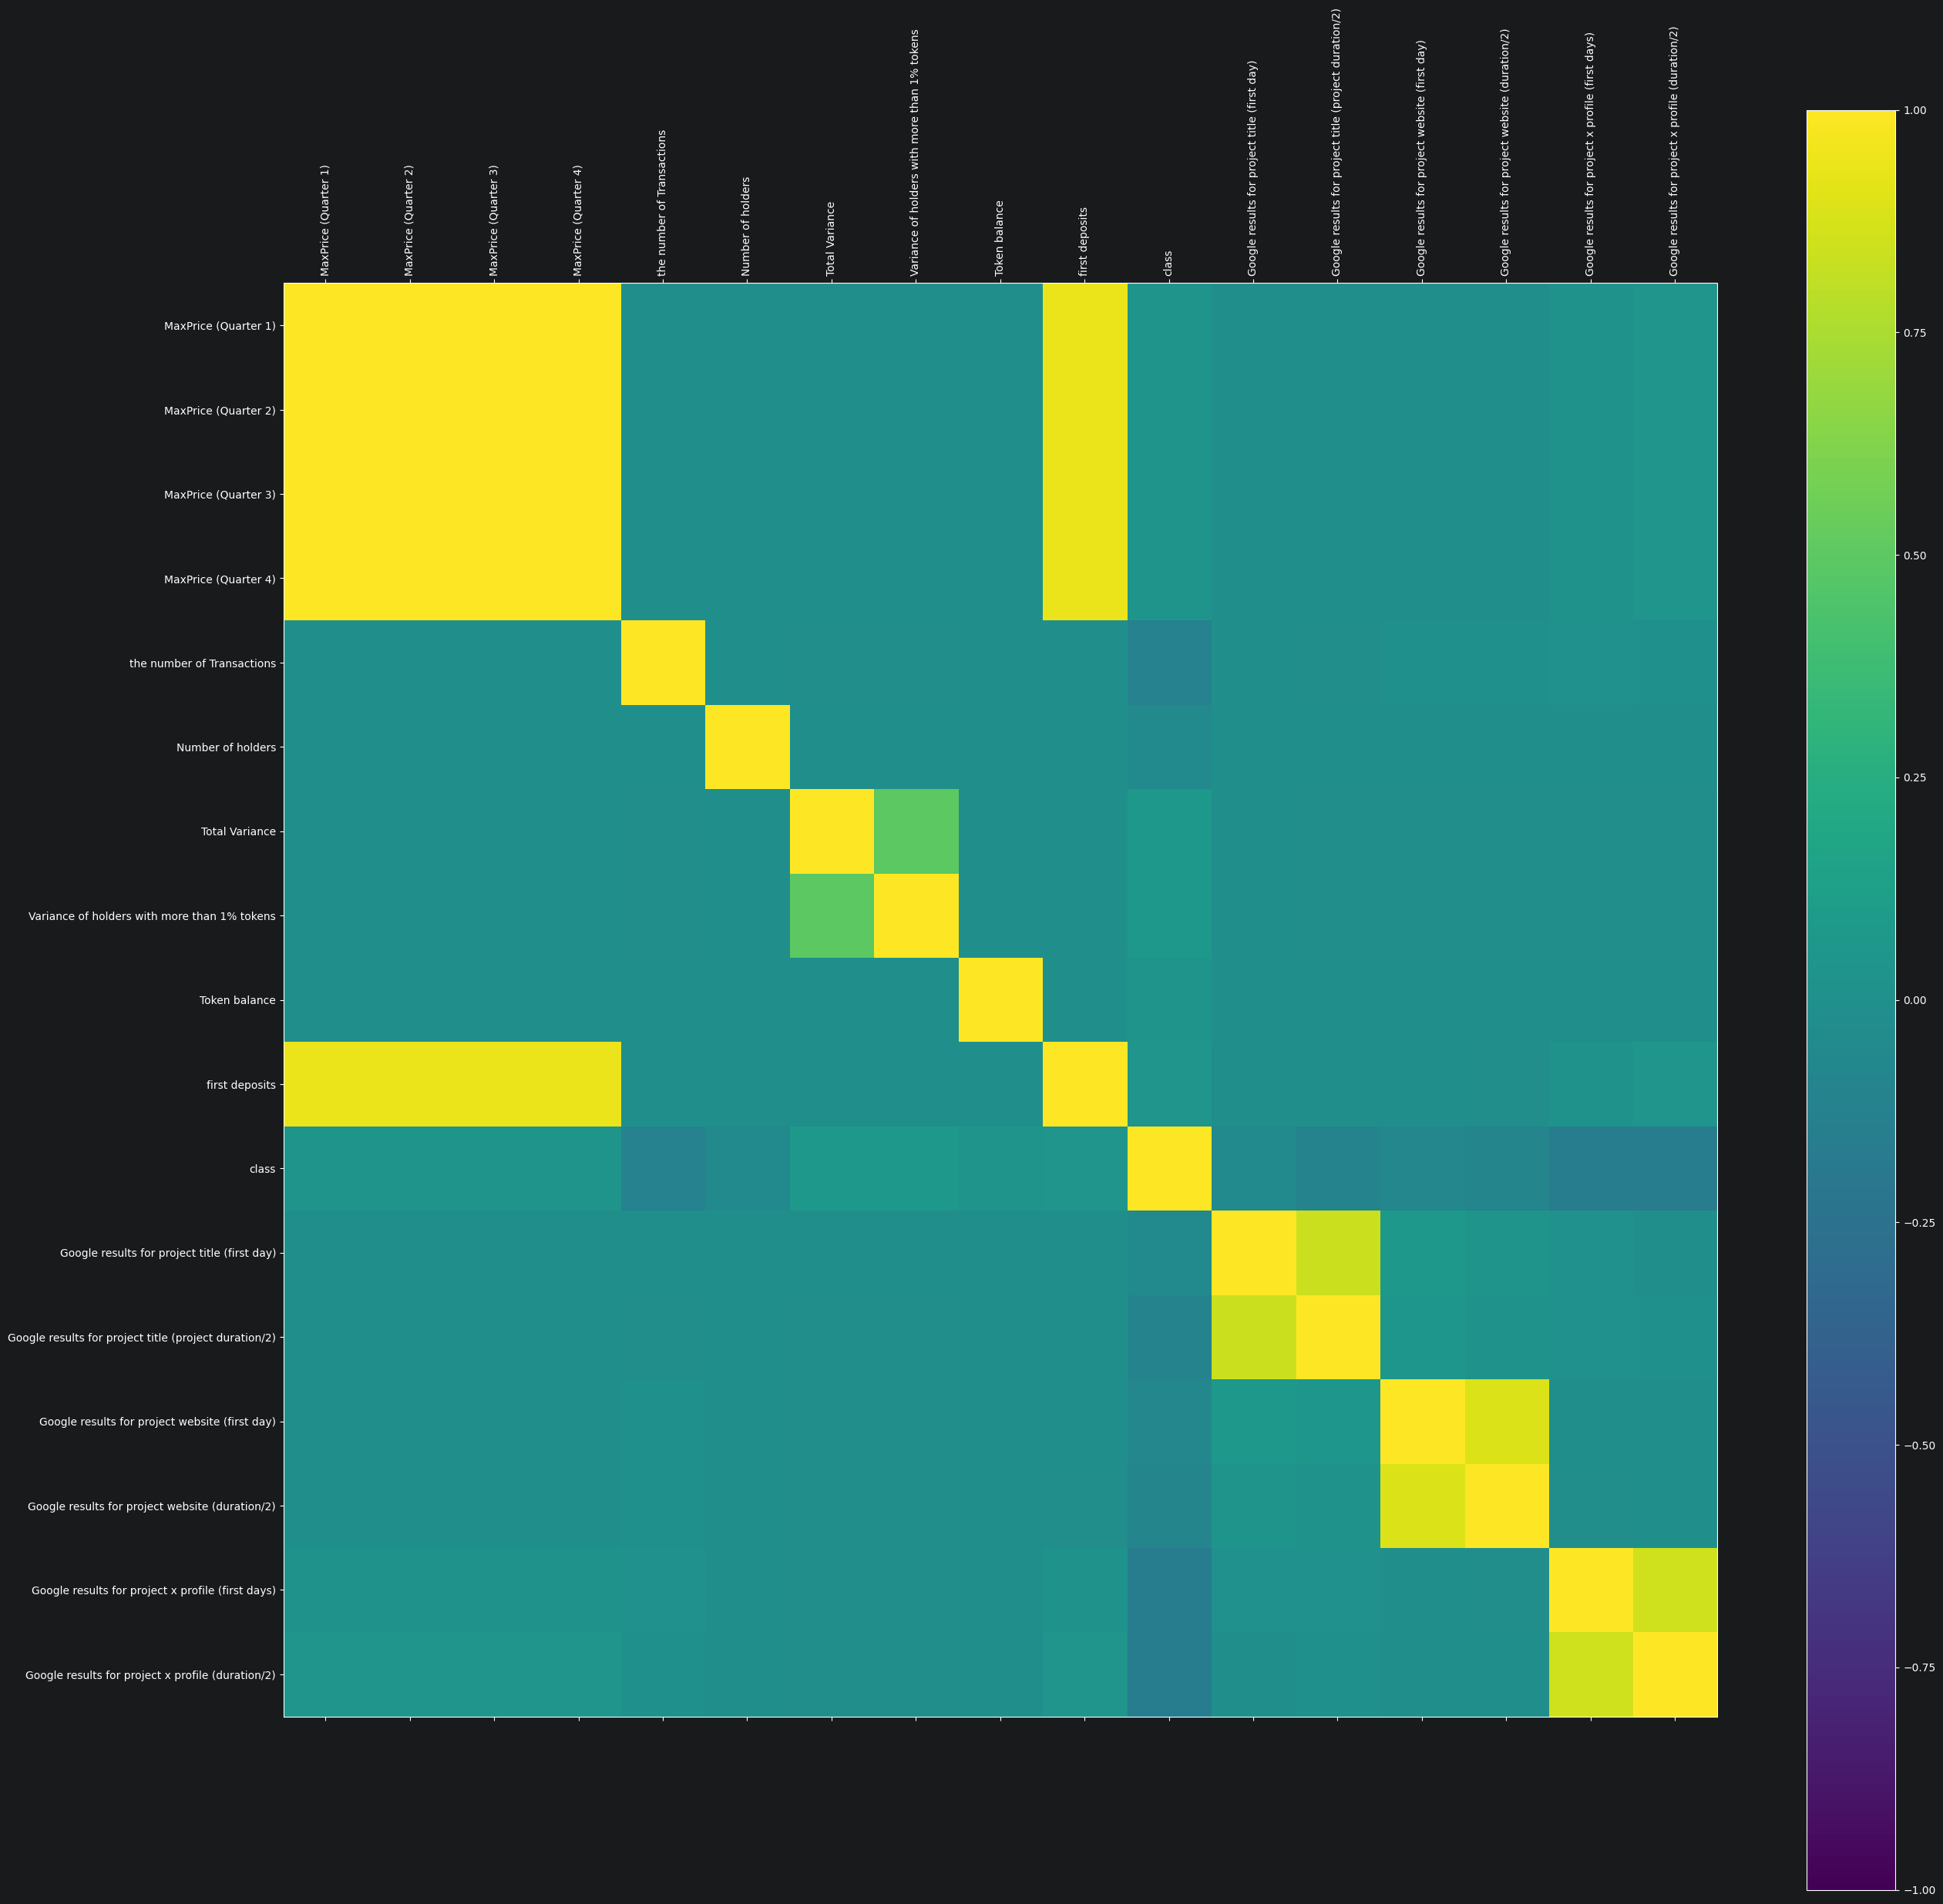

In [25]:
# Correlation Matrix Plot

fig = pyplot.figure(figsize=[30, 30])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(len(correlations.columns))

ax.set_xticks(ticks)
ax.set_yticks(ticks)

short_names = list(train_set[numeric_cols].columns)

ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)

pyplot.xticks(rotation=90)     # https://www.geeksforgeeks.org/how-to-rotate-x-axis-tick-label-text-in-matplotlib/?ysclid=lxdkiwmkrh456759424

pyplot.show()

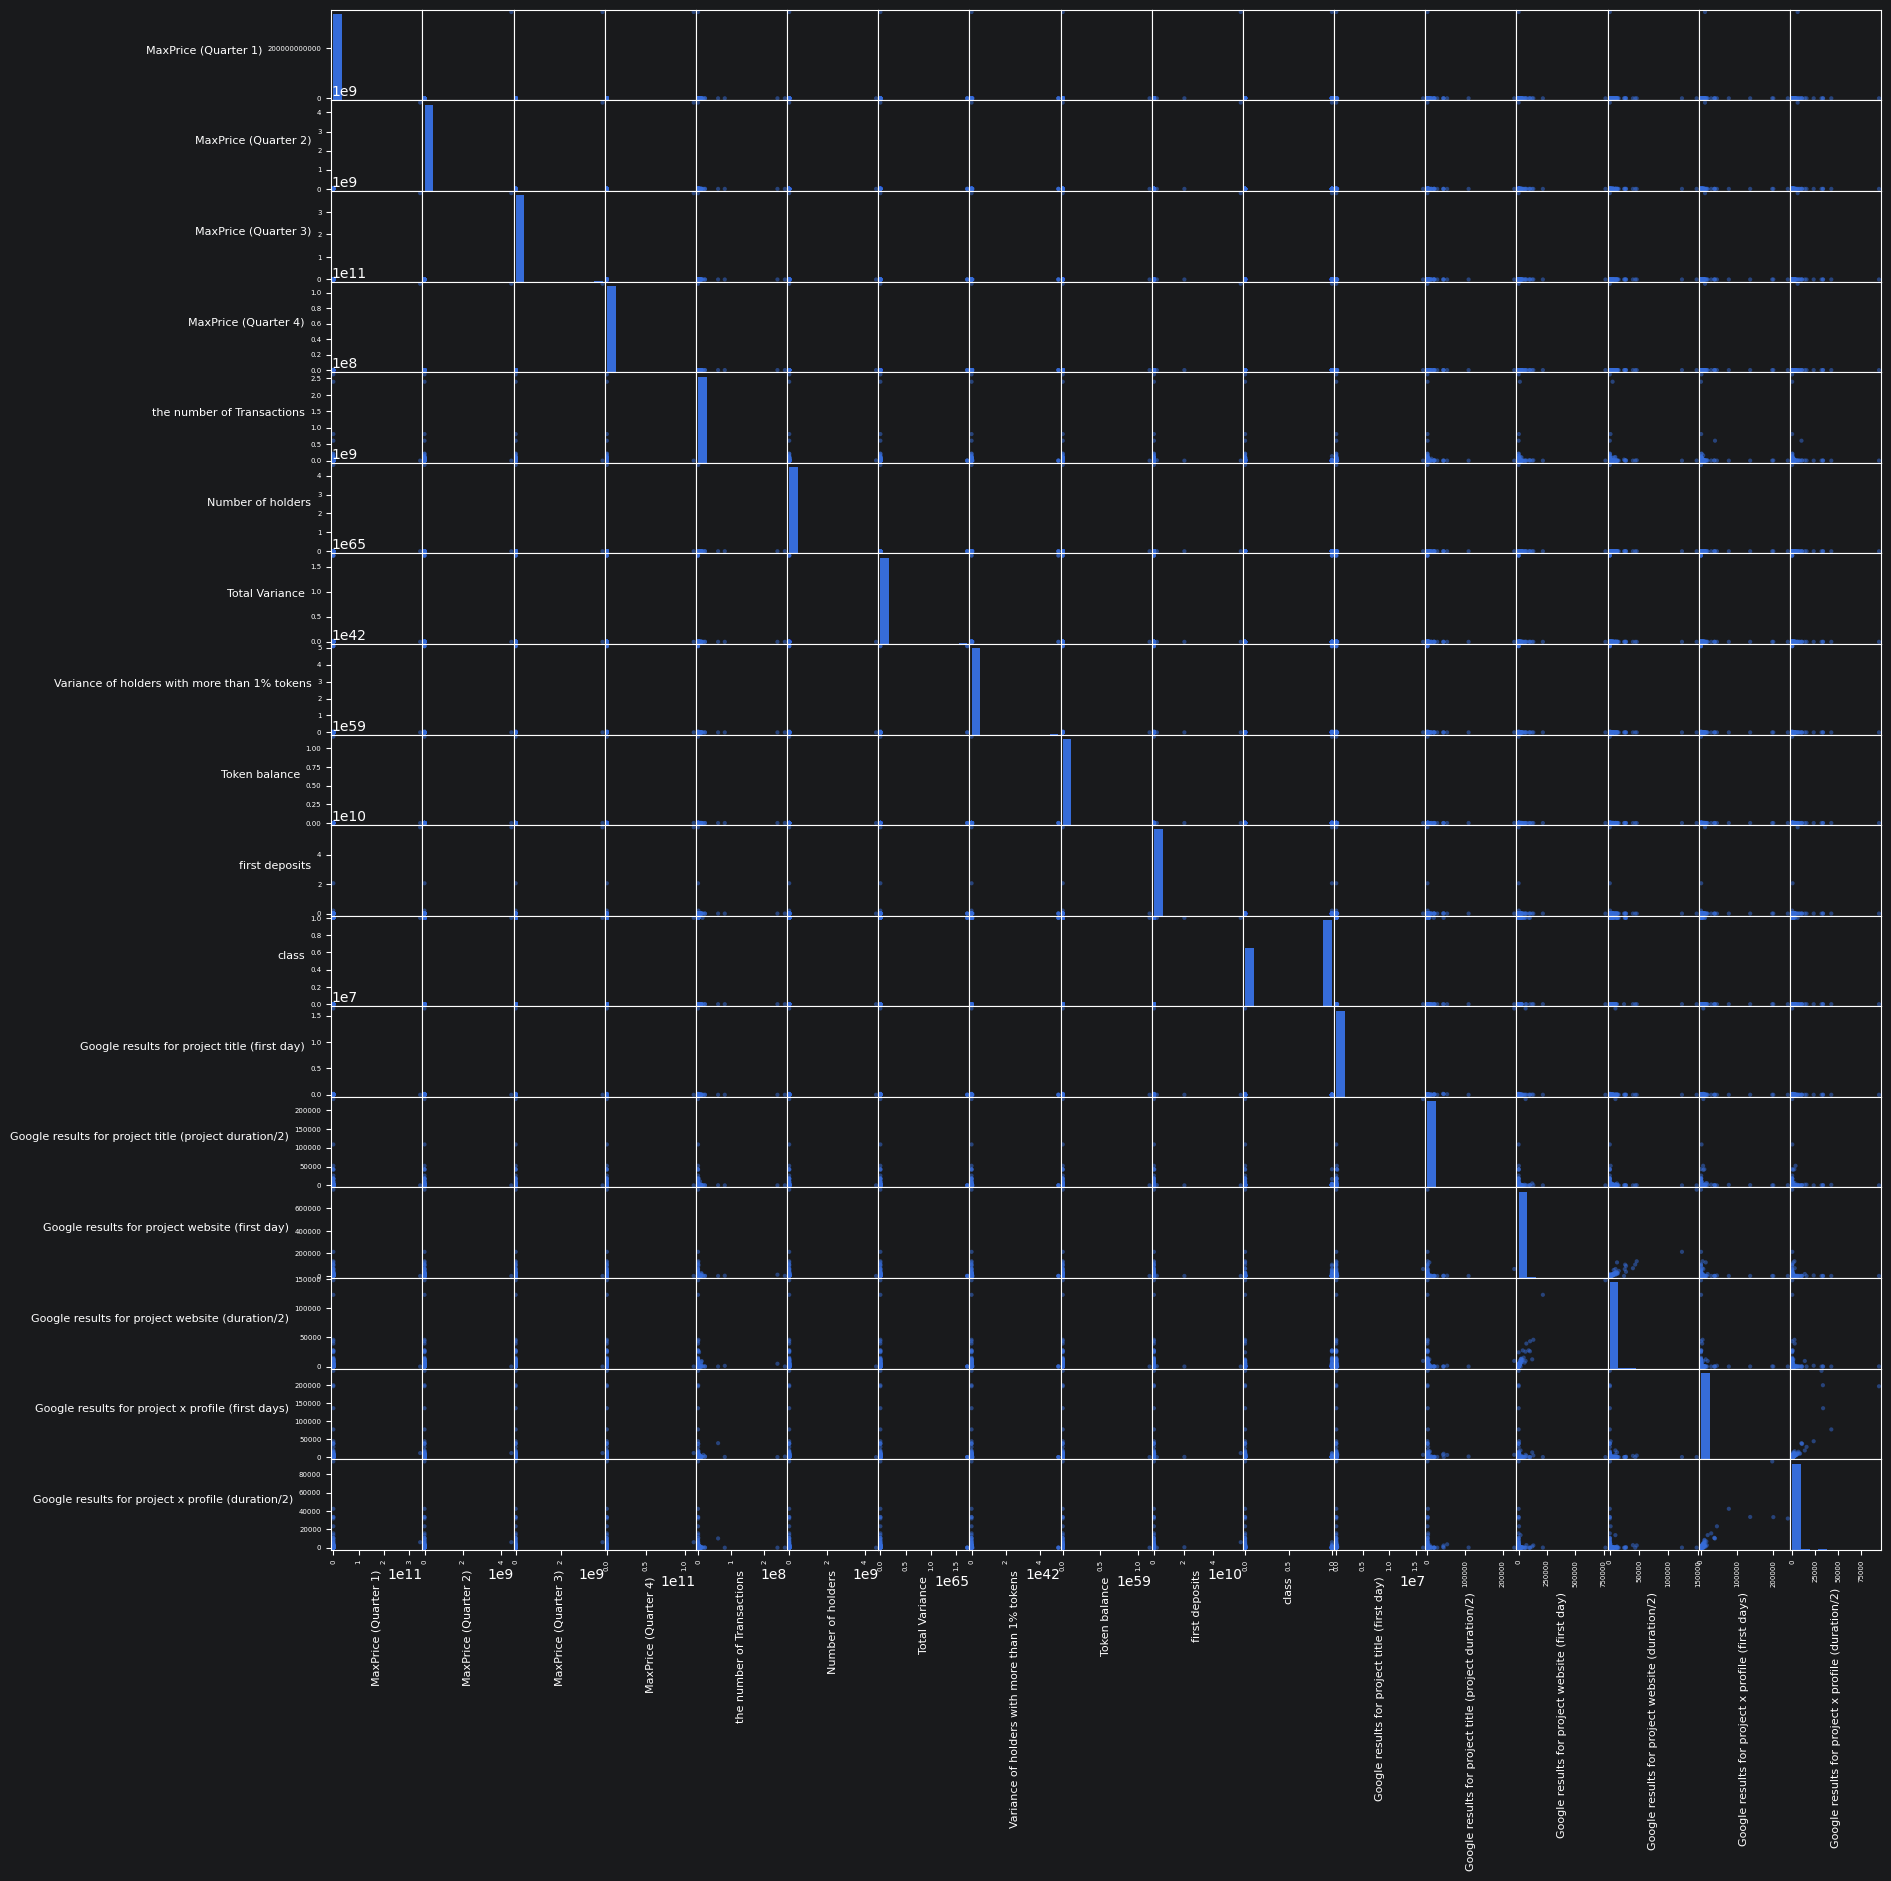

In [26]:
# Scatter plot Matrix

axes = pd.plotting.scatter_matrix(train_set[numeric_cols], figsize=(20, 20))

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.label.set_rotation(90)
        ax.yaxis.label.set_rotation(0)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
        ax.tick_params(axis='both', labelsize=5)

        # Shift y labels left
        ax.yaxis.set_label_position("left")
        ax.yaxis.label.set_horizontalalignment('right')
        ax.yaxis.label.set_x(-0.2)

pyplot.show()

##### Correlation matrix shows strong correlation (almost 1.0) between 'first deposits' and 'Q1'. Manual analysis revealed that 'first deposits' column is likely to be corrupted, since a lot of samples have the same float value here as in 'Q1' column, although it should be an integer. Thus, it should be deleted to avoid data contamination.

##### Based on results of raw data analysis, some pre-processing is required. In the following sections different levels of pre-processing will be tried. At first, minimal pre-processing without transformation will be applied (handling missing values, encode categorical features, clipping extreme outliers). Secondly, heavy skew will be handled using data transformation.

##### Then the following scenarios will be evaluated:
##### - train all candidate models on minimally pre-processed data (without transformation, but with clipped outliers);
##### - train all candidate models on transformed version of data, but without clipping.

##### Rescaling will be applied to models that are sensitive to scales.

## Minimal pre-processing of data

##### Based on results of raw data analysis, some pre-processing is required in order to run most models. For example, extreme outliers with enormous values results in ValueError during model training. In this section, minimal pre-processing will be applied (handling missing values, encoding categorical features, dealing with extreme outliers) in order to make the dataset suitable for model training.

In [27]:
# Remove 'first deposits' manually, since it seems to be corrupted (in majority cases it reproduces Q1 figures, which are prices, not deposits count)

for data_set in data_sets:
    data_set.drop(columns=['first deposits'], inplace=True)

train_set

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
949,34.000000,12.400000,5.780000,2.000000,ETH,130689.0,6727,1.072607e+14,2.309422e+17,1.000000e+09,POS,0,1890,994,42.0,6.0,745,437
335,0.199638,0.010277,0.030425,0.032866,ETH,54323.0,18323,2.457802e+12,4.323626e+15,5.000000e+08,POS,1,166,42,114.0,42.0,379,216
487,0.048000,0.091900,0.074000,0.041500,ETH,26448.0,5678,6.689802e+11,1.068798e+14,3.316141e+08,POS,1,4,3,40.0,42.0,5,3
710,88.000000,74.000000,75.000000,66.000000,ETH,416850.0,70956,6.841864e+06,1.873493e+10,2.863050e+06,POS,0,7,4,28.0,10.0,349,65
685,79.000000,108.000000,73.000000,4489.000000,ETH,24654.0,908,1.199781e+14,3.229262e+14,2.985311e+09,POS,0,0,0,214000.0,123000.0,261,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,4.430000,2.140000,0.603000,0.870000,BSC,4715912.0,177817,6.750565e+11,6.191921e+15,5.000000e+08,POSA,0,490,177,96.0,9.0,2870,1840
632,1.206000,1.040000,1.017000,1.084000,ETH,262543621.0,6313774,1.624152e+15,9.777368e+18,6.093919e+10,POS,0,1310,3,493.0,11.0,1330,42
273,0.000803,0.000019,0.000027,0.000038,ETH,11520.0,911,6.245692e+16,9.148279e+18,1.000000e+10,POS,1,4,3,1.0,0.0,47,47
36,0.531024,0.597108,0.508997,0.384172,BSC,90922.0,788,9.943130e+10,6.183796e+12,2.100000e+07,POSA,1,1920,703,0.0,0.0,0,0


In [28]:
# Handle missing values (for numeric 'median' is used due to heavy skew, for categorical values 'most frequent' is used).
# SimpleImputer is trained for all numeric and categorical columns (not only for ones with missing values) to be able to handle possible future missing values.

# Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

from sklearn.impute import SimpleImputer

# Define numeric and categorical columns
numeric_cols = train_set.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_set.select_dtypes(exclude=['number']).columns.tolist()

# Create inputers and fit to train set
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer.fit(train_set[numeric_cols])
cat_imputer.fit(train_set[categorical_cols])

# Apply to train and test sets
for data_set in [train_set, test_set]:
    data_set[numeric_cols] = num_imputer.transform(data_set[numeric_cols])
    data_set[categorical_cols] = cat_imputer.transform(data_set[categorical_cols])

# Verify it works (no missing values left)
print("\nRemaining missing values per column in train_set:")
print(train_set.isnull().sum())


Remaining missing values per column in train_set:
MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Number of holders                                        0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (duration/2)          0
Googl

In [29]:
# Determine unique categories for 'Blockchain' and 'Blockchain Type' columns

print(data_sets[0]['Blockchain'].unique())
print(data_sets[0]['Blockchain Type'].unique())

['ETH' 'BSC' 'ARBI' 'POLYGON']
['POS' 'POSA' 'Fraud Proofs']


In [30]:
# Encode categorical features ('Blockchain', 'Blockchain Type') to make all features numeric.
# OneHotEncoder was chosen, since the number of categories is small (4 for 'Blockchain' and 3 for 'Blockchain Type'),
# and OneHotEncoder prevents algorithms to treat close values more similar than distant ones.

# Based on: Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Blockchain', 'Blockchain Type']
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoder.fit(train_set[categorical_cols])

# Apply to each split
for data_set in [train_set, test_set]:
    cat_array = cat_encoder.transform(data_set[categorical_cols])
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    cat_df = pd.DataFrame(cat_array, columns=cat_feature_names, index=data_set.index)

    # Drop original categorical columns
    data_set.drop(columns=categorical_cols, inplace=True)

    # Add encoded columns
    for col in cat_df.columns:
        data_set[col] = cat_df[col]

# Verify it works (all columns are numeric)
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
the number of Transactions                               float64
Number of holders                                        float64
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                            float64
class                                                    float64
Google results for project title (first day)             float64
Google results for project title (project duration/2)    float64
Google results for project website (first day)           float64
Google results for project website (duration/2)          float64
Google results for project x profile (first days)        float64
Google results for projec

In [31]:
# Determine how many extreme outliers are in dataset.
# Several numeric features contains extreme values like 10ˆ40 or 10ˆ60, that cannot be handled by estimators and produce an error (Input X contains infinity or a value too large for dtype('float32')).

# Reference: https://numpy.org/devdocs/reference/generated/numpy.finfo.html

MAX_F32 = np.finfo(np.float32).max

def count_above_f32(df, name):
    arr = df[numeric_cols].to_numpy()
    above = np.abs(arr) > MAX_F32
    n_above = np.count_nonzero(above)
    total = arr.size

    print(f"{name}: values above float32 max: {n_above} ({n_above / total:.6%})")

count_above_f32(train_set, "train_set")
count_above_f32(test_set,  "test_set")

train_set: values above float32 max: 45 (0.424208%)
test_set: values above float32 max: 12 (0.229358%)


In [32]:
# Extract feature names (except 'class') for further interpretability

feature_names = train_set.columns.drop("class").tolist()

print(feature_names)

['MaxPrice (Quarter 1)', 'MaxPrice (Quarter 2)', 'MaxPrice (Quarter 3)', 'MaxPrice (Quarter 4)', 'the number of Transactions', 'Number of holders', 'Total Variance', 'Variance of holders with more than 1% tokens', 'Token balance', 'Google results for project title (first day)', 'Google results for project title (project duration/2)', 'Google results for project website (first day)', 'Google results for project website (duration/2)', 'Google results for project x profile (first days)', 'Google results for project x profile (duration/2)', 'Blockchain_ARBI', 'Blockchain_BSC', 'Blockchain_ETH', 'Blockchain_POLYGON', 'Blockchain Type_Fraud Proofs', 'Blockchain Type_POS', 'Blockchain Type_POSA']


In [33]:
# Clip extreme values to make data suitable for model training (applied to copies of data, since this step is not relevant
# after transformation (see next section)).
# Clipping is performed for values above float32 datatype capacity.

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.

train_minimal = train_set.copy()
test_minimal  = test_set.copy()

numeric_cols_minimal = train_minimal.select_dtypes(include=['number']).columns.tolist()

# Clip everything to float32 capacity
for data_set in [train_minimal, test_minimal]:
    data_set[numeric_cols_minimal] = data_set[numeric_cols_minimal].clip(upper=MAX_F32)

# Verify that no data left that exceeds float32 capacity
for name, data_set in zip(
    ['train_minimal', 'test_minimal'],
    [train_minimal, test_minimal]
):
    arr = data_set[numeric_cols_minimal].to_numpy()
    print(f"{name}: any > MAX_F32? {(np.abs(arr) > MAX_F32).any()}")

train_minimal: any > MAX_F32? False
test_minimal: any > MAX_F32? False


In [34]:
# Separate features from the target variable for minimally pre-processed dataset.
# Extract X and Y from train and test sets after minimal pre-processing.

# Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

X_train_minimal = train_minimal.drop(columns=['class']).values
Y_train_minimal = train_minimal['class'].values

X_test_minimal = test_minimal.drop(columns=['class']).values
Y_test_minimal = test_minimal['class'].values

## Data transformation

##### Due to extreme skew, some data transformation is conducted in order to improve performance of models. Firstly, log1p transformation has been attempted, resulting in reducing skew to small to moderate values, but several features were still heavily skewed. Thus, PowerTransformer has been applied to find a power that is the most effective in reducing skew for the dataset.

##### Data after this step of pre-processing also will be used for plotting to assess the effect of data transformation.

In [35]:
# Transform data to deal with skew.
# For columns with heavy skew PowerTransformer is applied

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

from sklearn.preprocessing import PowerTransformer

skewed_cols = [
    'MaxPrice (Quarter 1)',
    'MaxPrice (Quarter 2)',
    'MaxPrice (Quarter 3)',
    'MaxPrice (Quarter 4)',
    'Total Variance',
    'Variance of holders with more than 1% tokens',
    'Token balance',
    'Number of holders',
    'the number of Transactions',
    'Google results for project title (first day)',
    'Google results for project title (project duration/2)',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)',
    'Google results for project x profile (first days)',
    'Google results for project x profile (duration/2)'
]

# Yeo-Johnson has been chosen, since it handles zeros safely. At this stage, no scaling is applied
pt = PowerTransformer(method='yeo-johnson', standardize=False)
pt.fit(train_set[skewed_cols].astype(float).values)

for data_set in [train_set, test_set]:
    data_set[skewed_cols] = pt.transform(data_set[skewed_cols].astype(float).values)

# Assess skew after transformation
skew = train_set.skew()
skew

MaxPrice (Quarter 1)                                     0.848599
MaxPrice (Quarter 2)                                     0.978989
MaxPrice (Quarter 3)                                     1.105894
MaxPrice (Quarter 4)                                     1.138294
the number of Transactions                              -0.014705
Number of holders                                       -0.002256
Total Variance                                          -0.035516
Variance of holders with more than 1% tokens            -0.085144
Token balance                                           -0.289077
class                                                   -0.391221
Google results for project title (first day)             0.068256
Google results for project title (project duration/2)    0.131033
Google results for project website (first day)           0.263012
Google results for project website (duration/2)          0.329738
Google results for project x profile (first days)        0.056984
Google res

In [36]:
# Make snapshots of moderately pre-processed data for further experimentation

train_transformed = train_set.copy()
test_transformed  = test_set.copy()

In [37]:
# Separate features from the target variable for transformed dataset
# Extract X and Y from train and test sets after transformation

# # Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

X_train_transformed = train_transformed.drop(columns=['class']).values
Y_train_transformed = train_transformed['class'].values

X_test_transformed = test_transformed.drop(columns=['class']).values
Y_test_transformed = test_transformed['class'].values

### Visualisation after data transformation

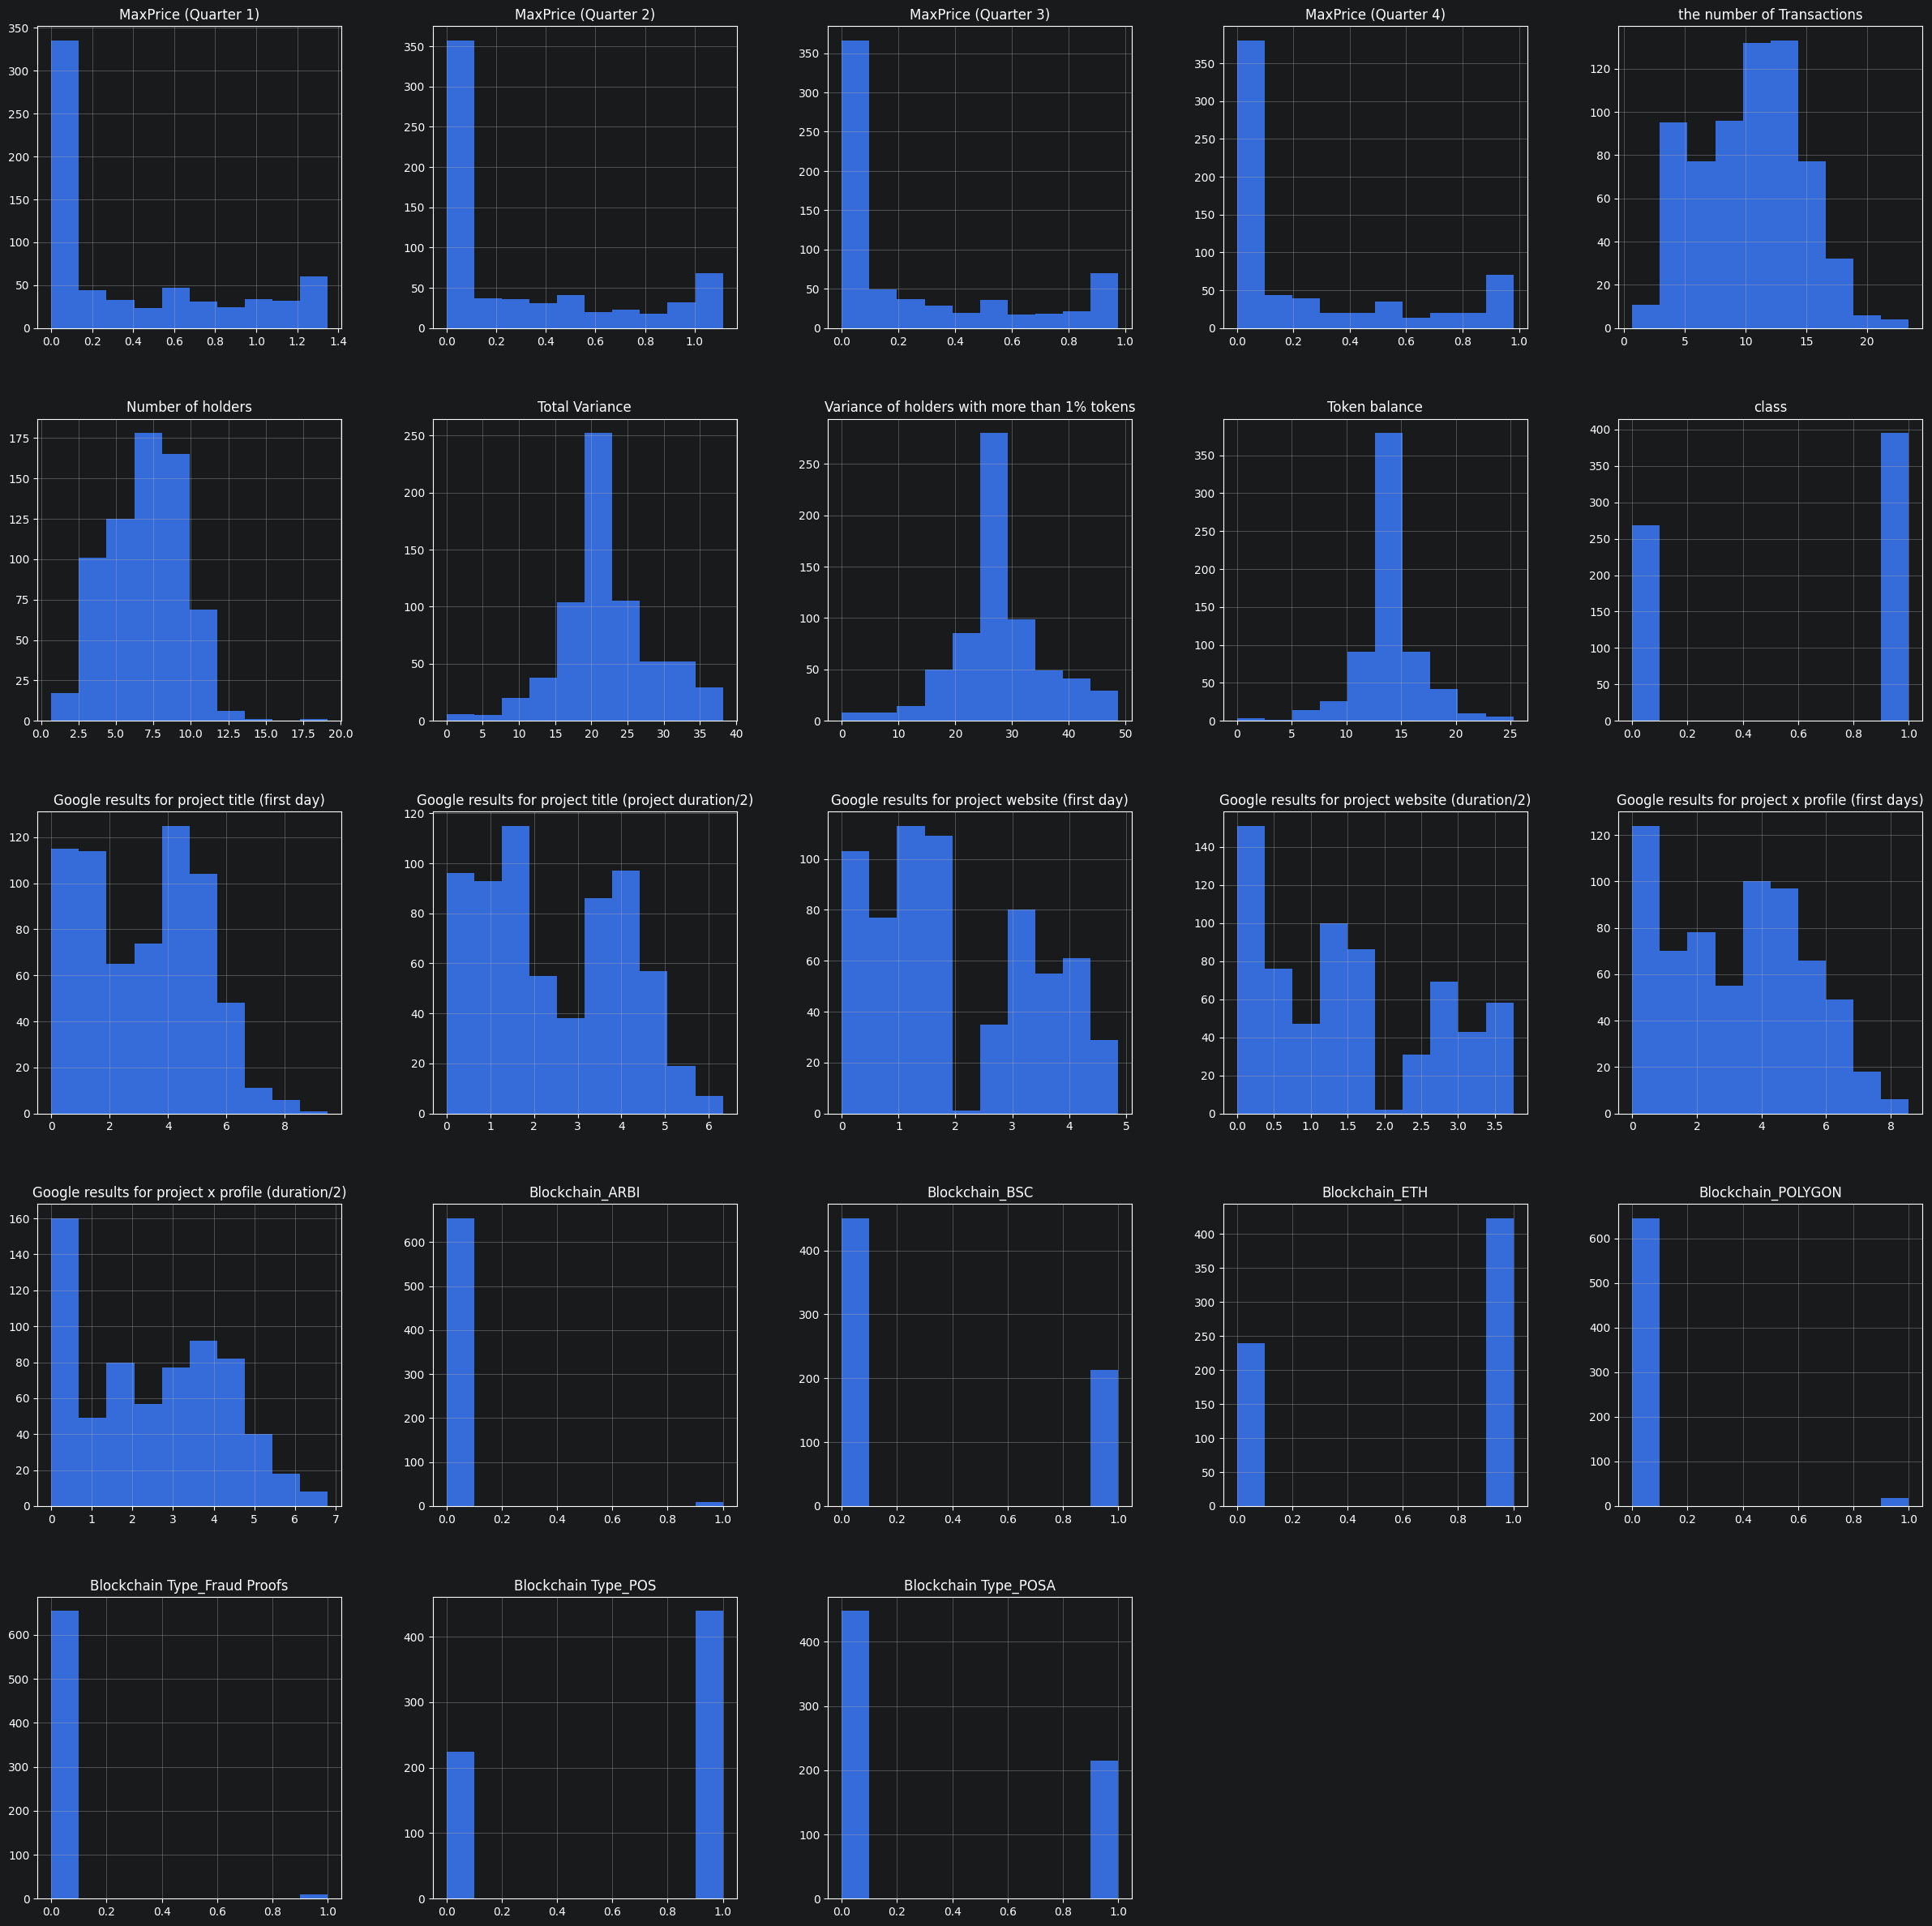

In [38]:
# Histograms after handling skew

train_transformed.hist(figsize=[30, 30])
pyplot.show()

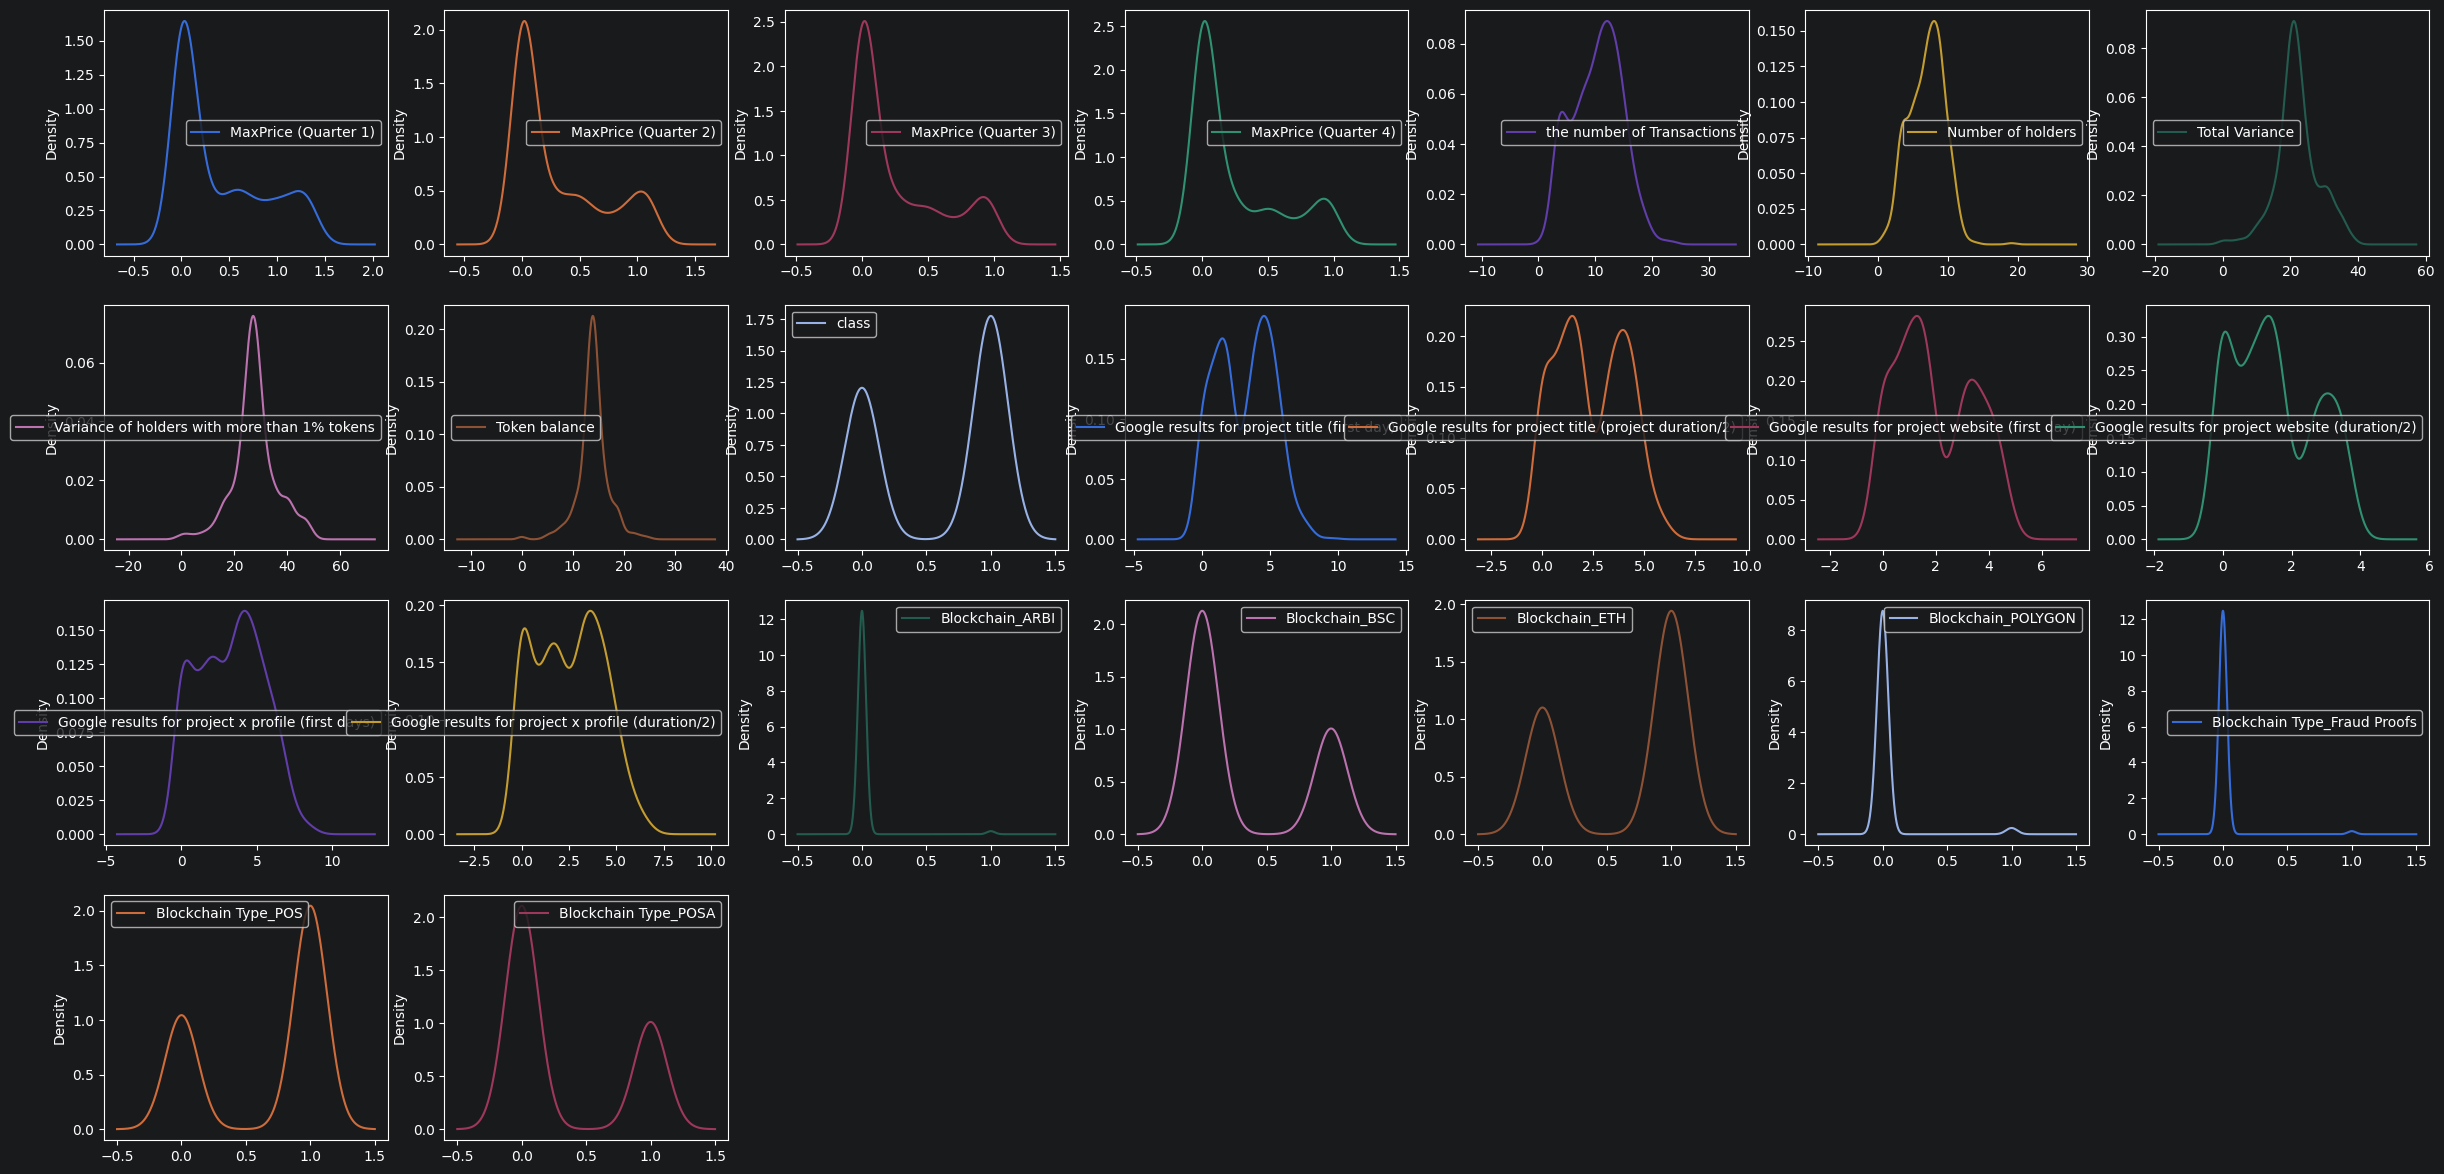

In [39]:
# Density plots after handling skew

train_transformed.plot(kind='density', subplots=True, layout=(8, 7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

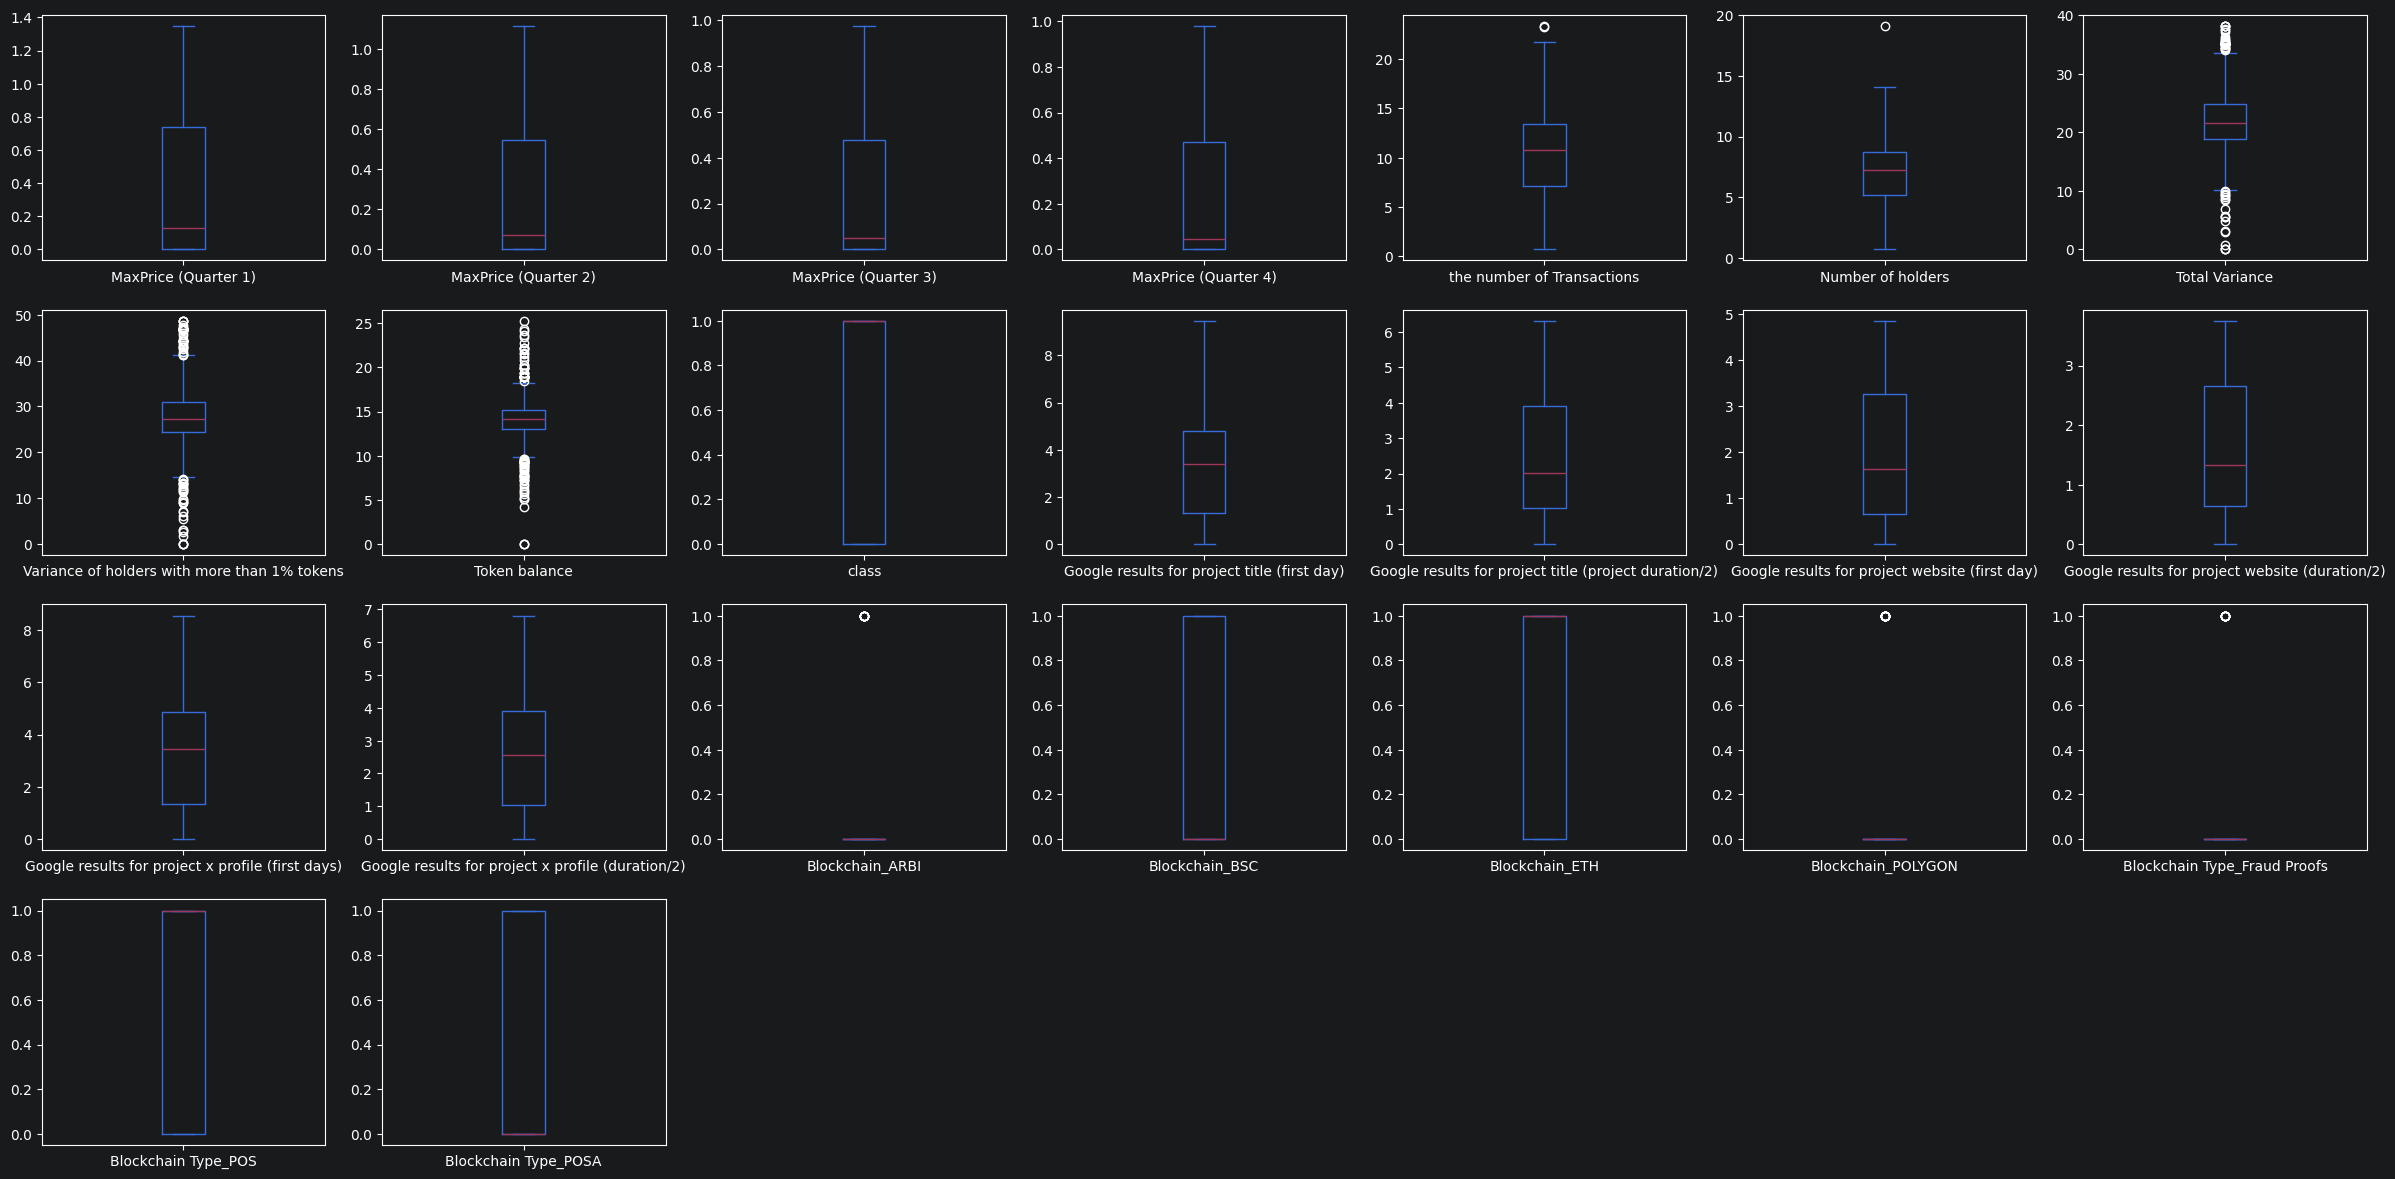

In [40]:
# Box and Whisker Plots after handling skew

train_transformed.plot(kind='box', subplots=True, layout=(8, 7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

In [41]:
# Search for correlations of numeric features after handling skew

correlations = train_transformed[numeric_cols].corr(method='pearson')

correlations

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),the number of Transactions,Number of holders,Total Variance,Variance of holders with more than 1% tokens,Token balance,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
MaxPrice (Quarter 1),1.000000,0.897246,0.839073,0.765602,0.301893,0.247077,-0.371930,-0.299717,-0.366381,-0.336087,0.229181,0.216408,0.219875,0.146909,0.286798,0.233867
MaxPrice (Quarter 2),0.897246,1.000000,0.929754,0.833726,0.302395,0.248870,-0.373529,-0.310170,-0.373898,-0.338326,0.244256,0.220390,0.212879,0.106589,0.303037,0.227500
MaxPrice (Quarter 3),0.839073,0.929754,1.000000,0.886299,0.280008,0.220190,-0.361394,-0.317666,-0.356362,-0.286543,0.233311,0.203122,0.191086,0.091881,0.276243,0.190791
MaxPrice (Quarter 4),0.765602,0.833726,0.886299,1.000000,0.250389,0.194142,-0.354974,-0.324612,-0.359827,-0.235083,0.236626,0.203698,0.157725,0.075144,0.253982,0.170537
the number of Transactions,0.301893,0.302395,0.280008,0.250389,1.000000,0.849191,-0.338059,-0.179705,-0.067533,-0.592232,0.316187,0.265515,0.172200,0.128428,0.438055,0.396821
Number of holders,0.247077,0.248870,0.220190,0.194142,0.849191,1.000000,-0.270655,-0.102737,0.040149,-0.582343,0.313002,0.262021,0.169243,0.120568,0.452121,0.411070
Total Variance,-0.371930,-0.373529,-0.361394,-0.354974,-0.338059,-0.270655,1.000000,0.817170,0.717044,0.285796,-0.126907,-0.117545,-0.062698,-0.022579,-0.140031,-0.131787
Variance of holders with more than 1% tokens,-0.299717,-0.310170,-0.317666,-0.324612,-0.179705,-0.102737,0.817170,1.000000,0.590815,0.171678,-0.099221,-0.093656,-0.002606,0.018638,-0.041614,-0.030015
Token balance,-0.366381,-0.373898,-0.356362,-0.359827,-0.067533,0.040149,0.717044,0.590815,1.000000,0.105806,-0.067491,-0.075909,-0.058513,-0.038090,-0.043824,-0.045253
class,-0.336087,-0.338326,-0.286543,-0.235083,-0.592232,-0.582343,0.285796,0.171678,0.105806,1.000000,-0.319624,-0.308820,-0.177137,-0.108984,-0.559767,-0.463563


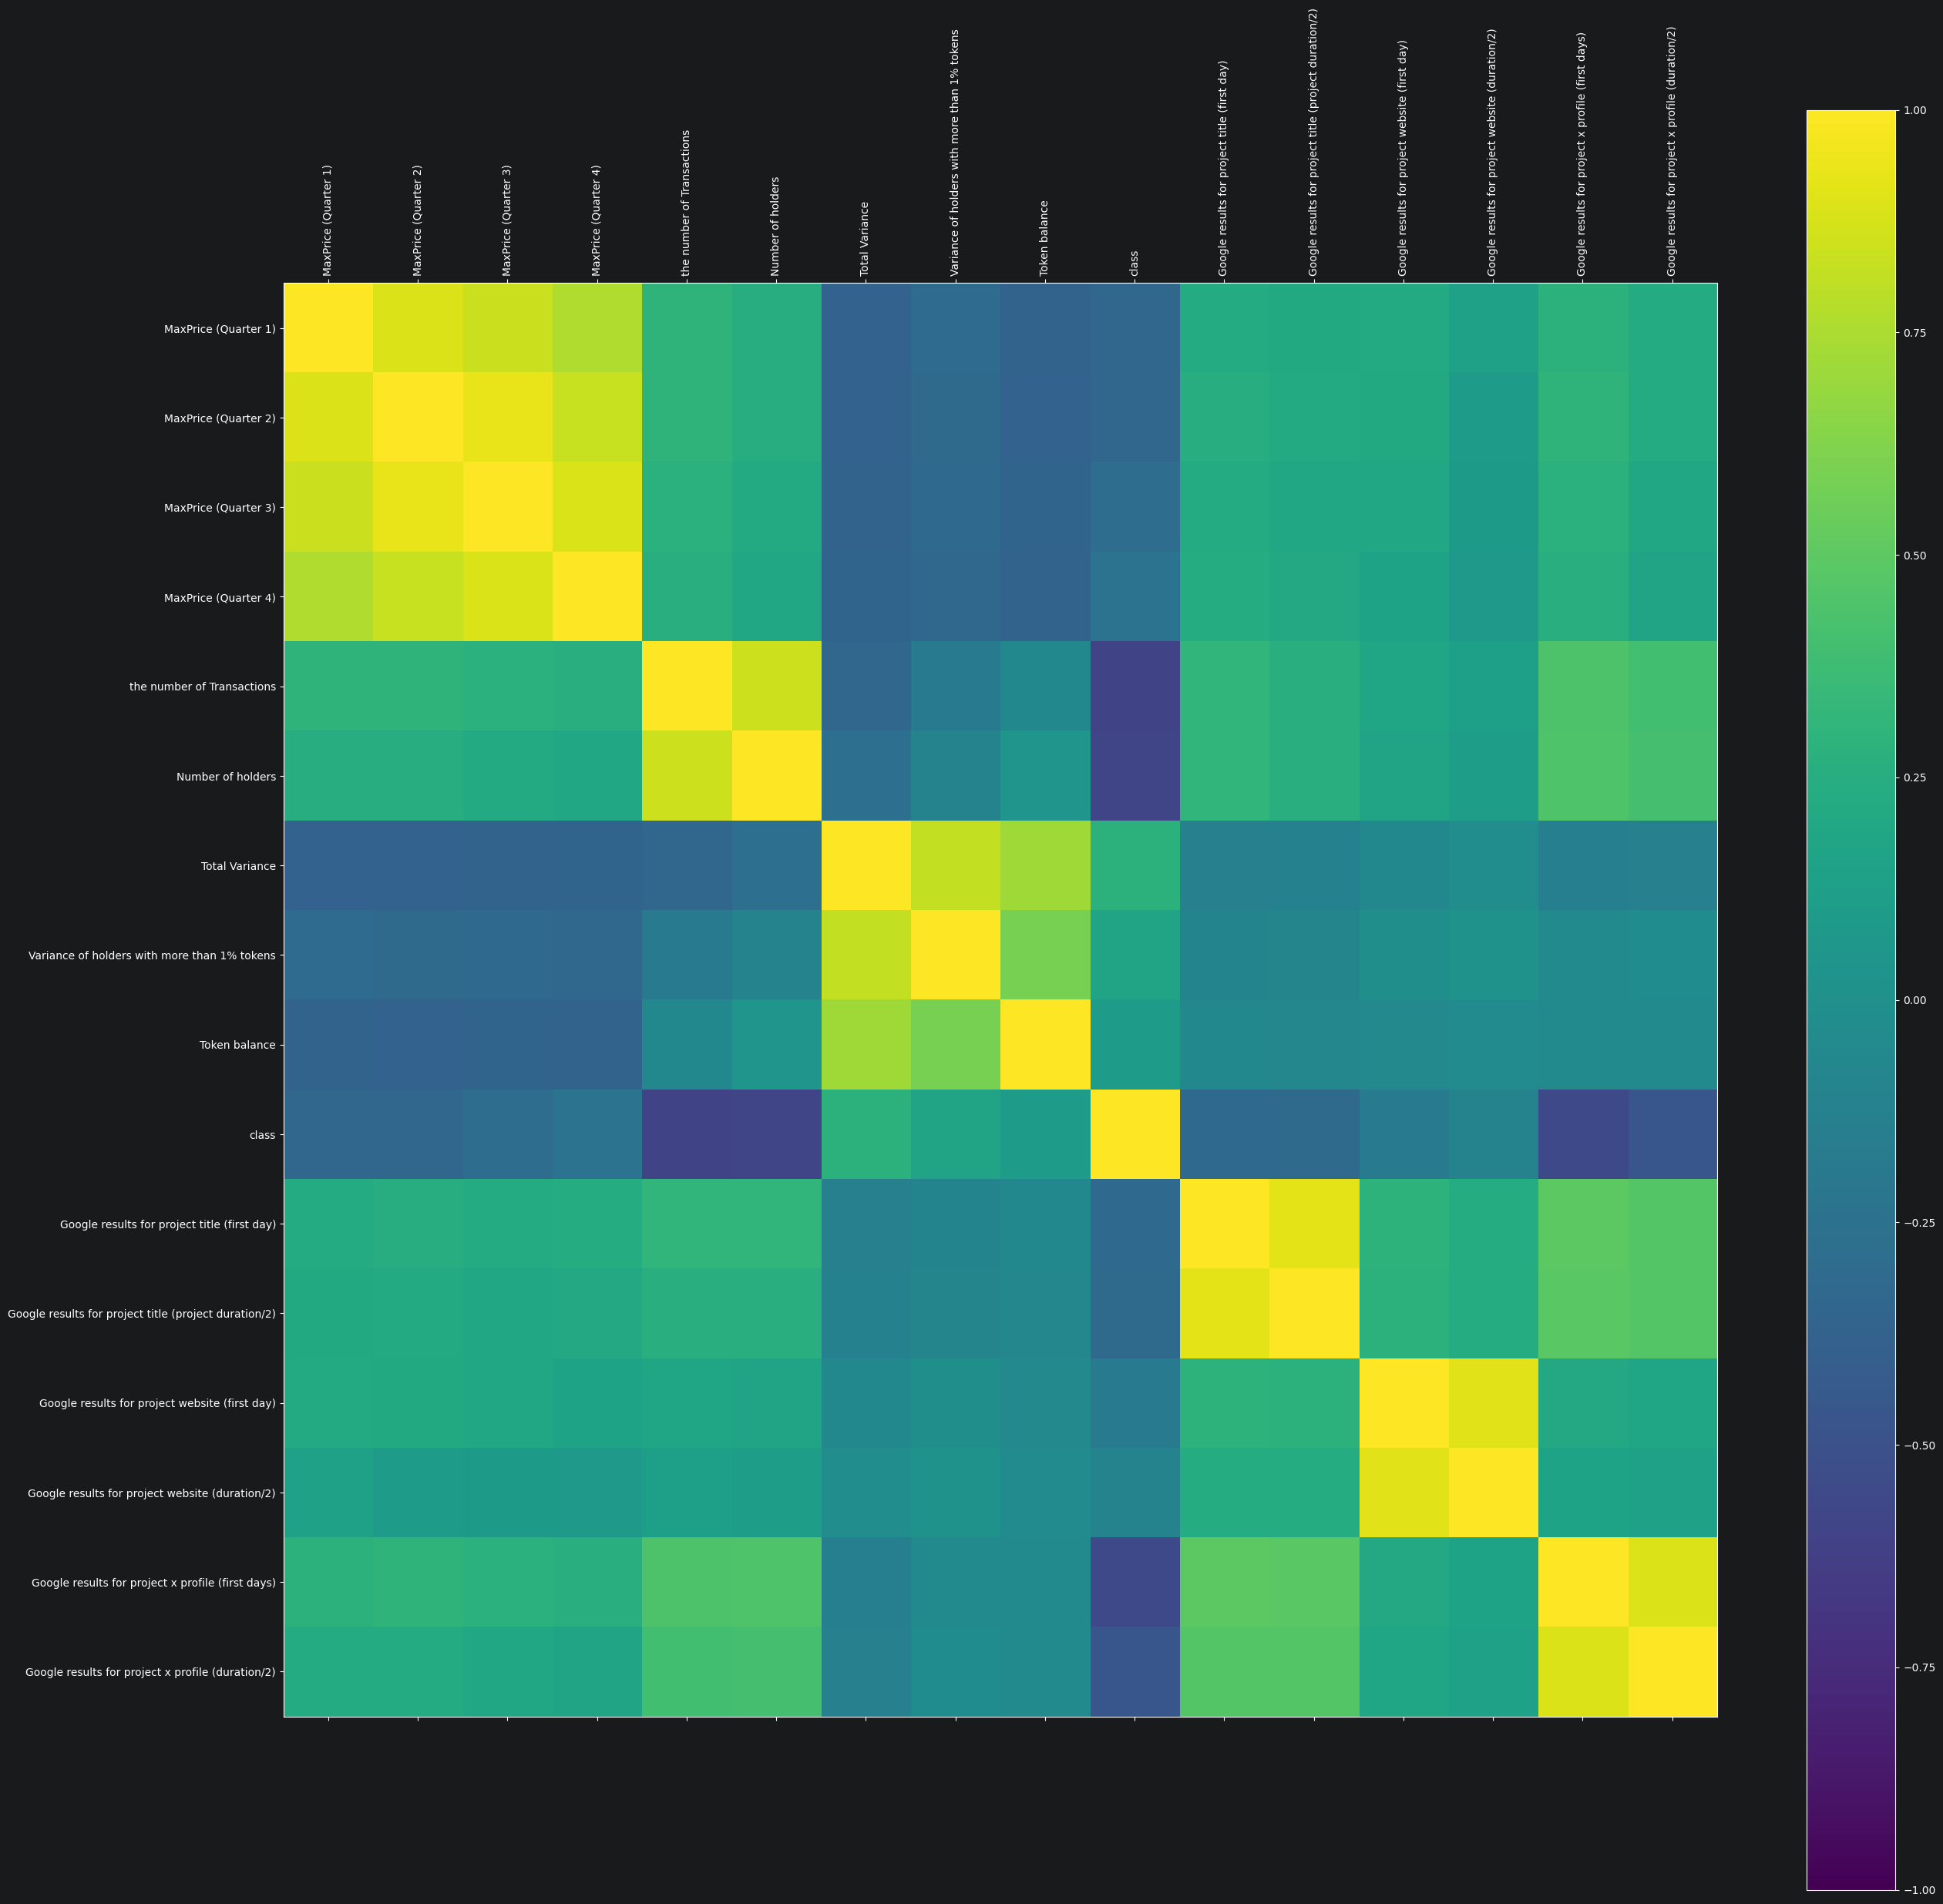

In [42]:
# Correlation Matrix Plot after handling skew

fig = pyplot.figure(figsize=[30, 30])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

numeric_cols = correlations.columns

ticks = np.arange(len(numeric_cols))

ax.set_xticks(ticks)
ax.set_yticks(ticks)

short_names = list(numeric_cols)

ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)

pyplot.xticks(rotation=90)     # https://www.geeksforgeeks.org/how-to-rotate-x-axis-tick-label-text-in-matplotlib/?ysclid=lxdkiwmkrh456759424

pyplot.show()

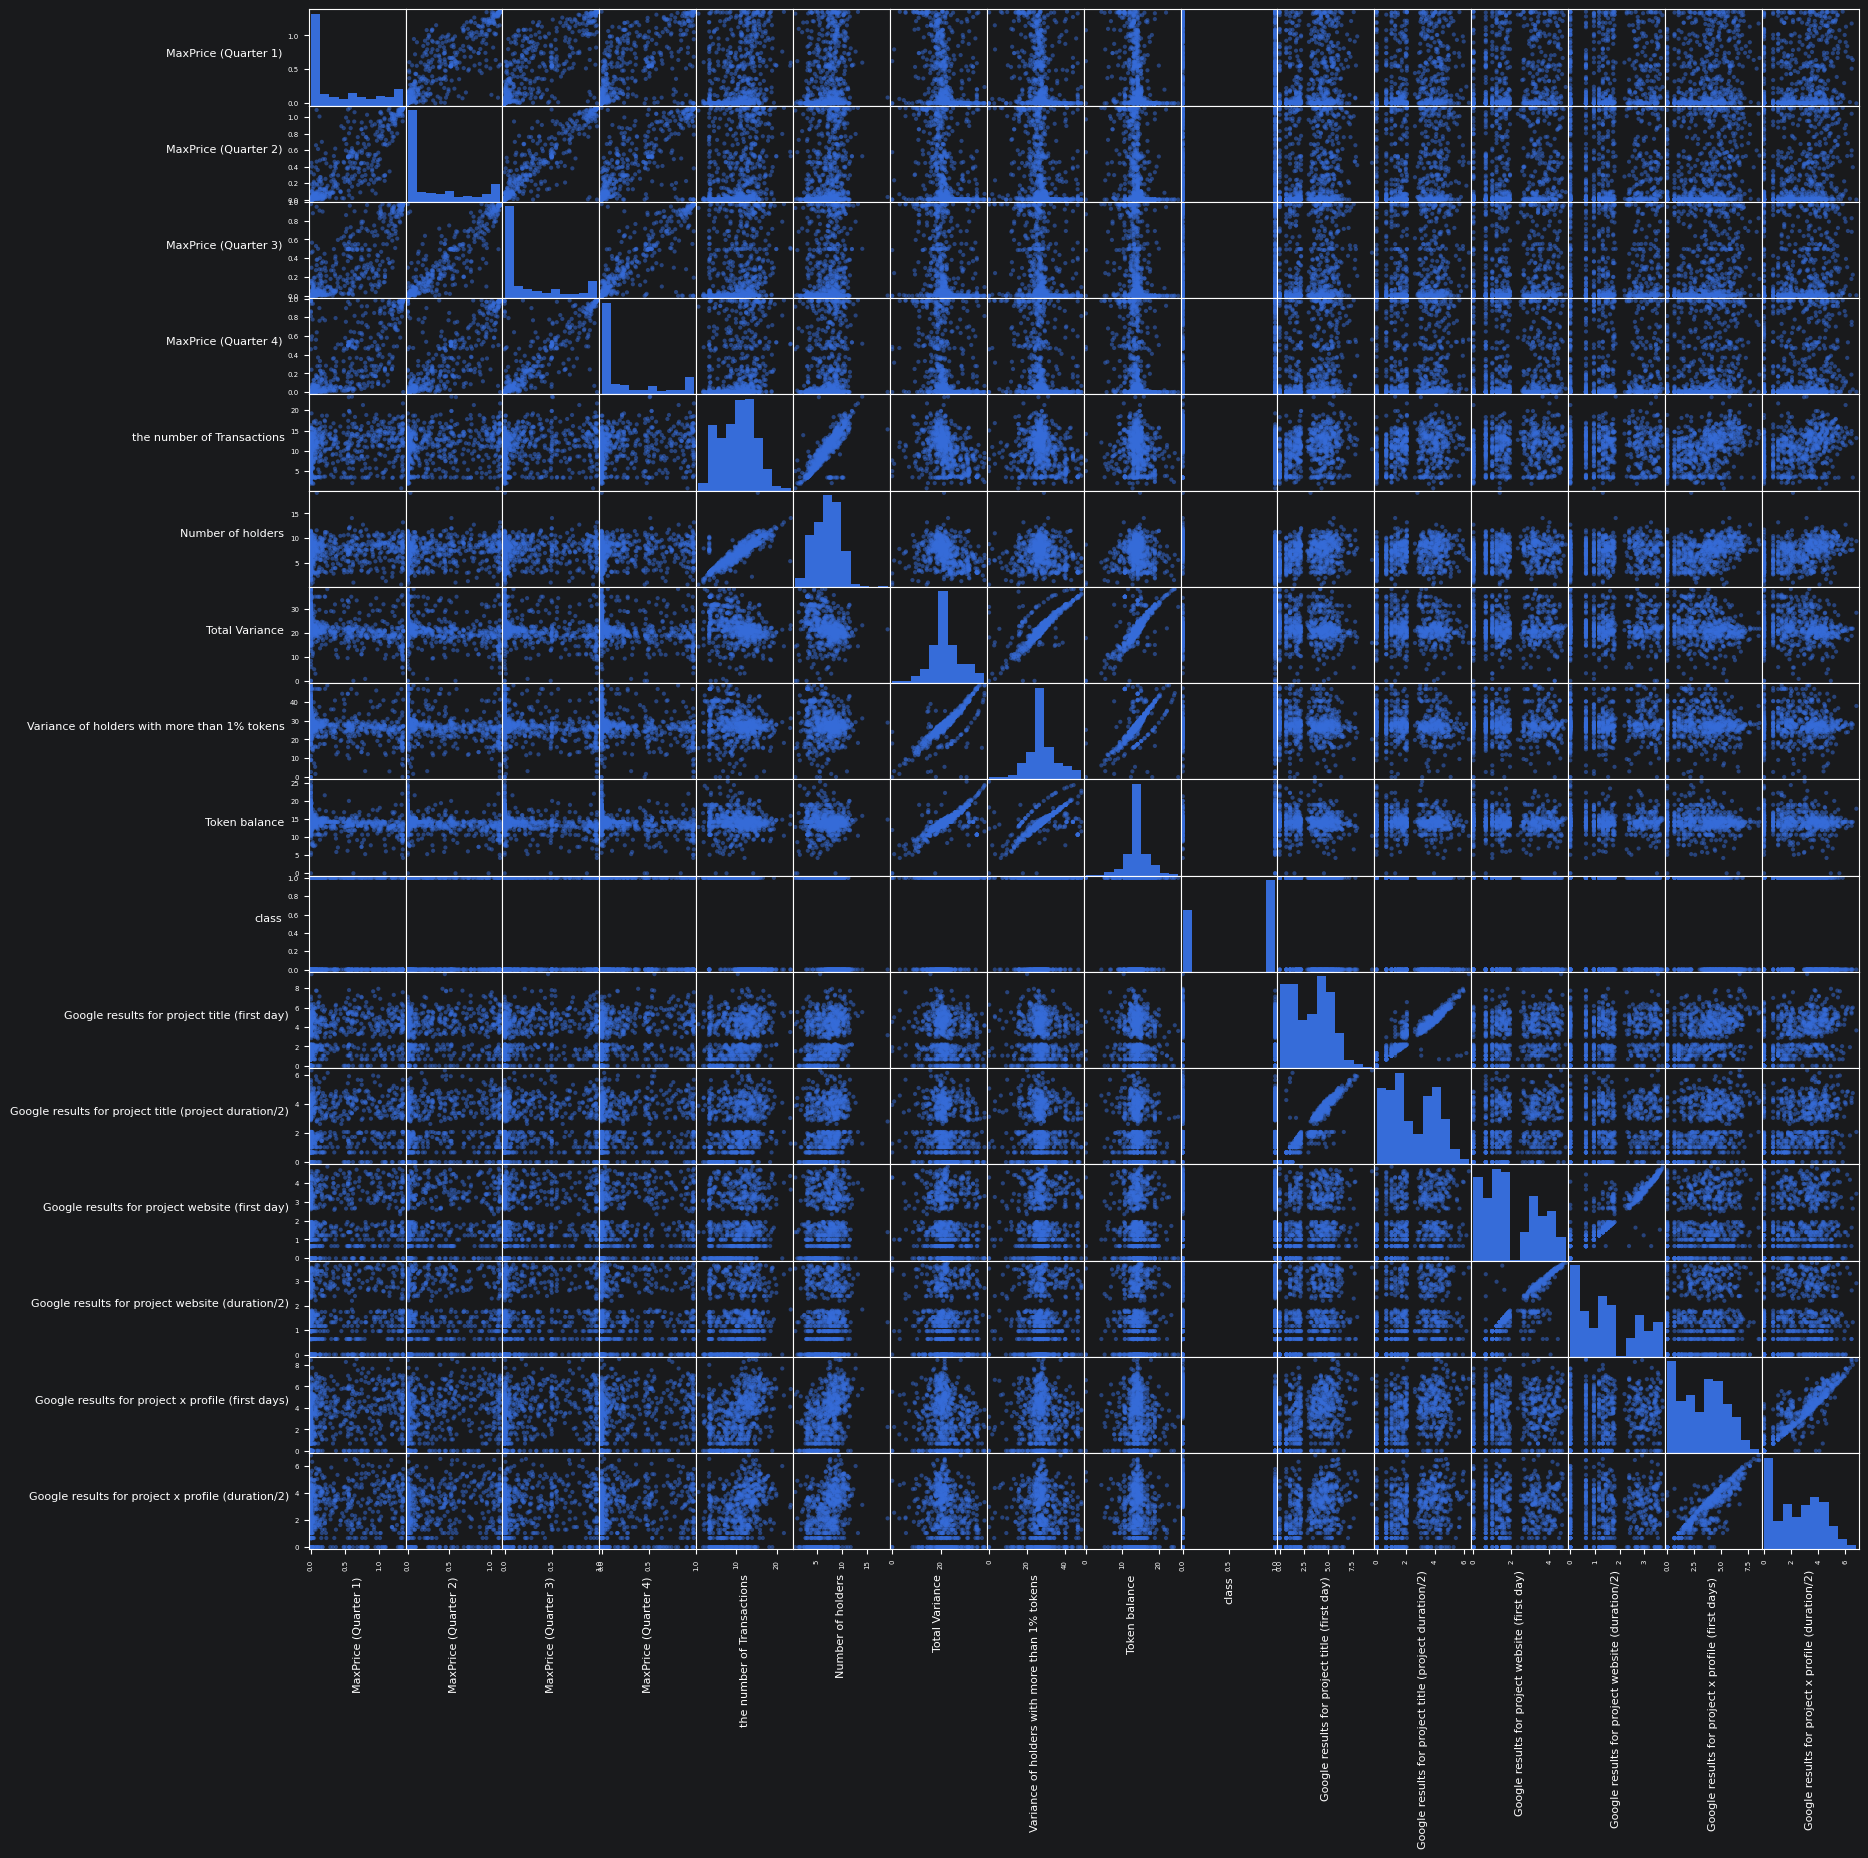

In [43]:
# Scatter plot Matrix after handling skew

# Reference: https://matplotlib.org/3.10.3/gallery/text_labels_and_annotations/align_ylabels.html

axes = pd.plotting.scatter_matrix(train_transformed[numeric_cols], figsize=(20, 20))

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.label.set_rotation(90)
        ax.yaxis.label.set_rotation(0)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
        ax.tick_params(axis='both', labelsize=5)

        # Shift y labels left
        ax.yaxis.set_label_position("left")
        ax.yaxis.label.set_horizontalalignment('right')
        ax.yaxis.label.set_x(-0.2)

pyplot.show()

## Training models

##### In this section initial model training is conducted to compare performance on differently pre-processed data. Results of this experiment are used only to choose pre-processing steps that better suit to general pipeline.

##### Preliminary model training shows that some models (SVC, LogisticRegression, LinearDiscriminantAnalysis, KNeighbors) cannot be properly trained on data without scaling, since they are scale-sensitive, and some features in data have different scales, which result in multiple warnings and errors. Thus, these models are always trained only on data after scaling (using StandardScaler or RobustScaler in Pipeline).

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Reference: K. Erofeeva, the coursework for CSM010-2024-APR module

# Create temporally-aware fold indices, stratified on both class and project period (combined label)
# to preserve the same temporal logic as train / test split.
# 5 folds are used, since the size of the dataset is quite small
# Reference: https://medium.com/@hlfzeus/stratified-splitting-with-stratifiedkfold-using-target-and-group-variables-part-2-eae4d9c7abf7
def make_temporal_kfold_splits(X, combined_labels, n_splits=5, seed=seed):
    stratified_folds = StratifiedKFold(n_splits=n_splits, random_state=seed, shuffle=True)
    return list(stratified_folds.split(X, combined_labels))

# Make pre-computed splits on train and test sets for further cross-validation
splits_train_minimal = make_temporal_kfold_splits(X_train_minimal, combined_labels_train)
splits_test_minimal = make_temporal_kfold_splits(X_test_minimal, combined_labels_test)

splits_train_transformed = make_temporal_kfold_splits(X_train_transformed, combined_labels_train)
splits_test_transformed = make_temporal_kfold_splits(X_test_transformed, combined_labels_test)

# Instantiate models
# For models that require scaling StandardScaler and RobustScaler are applied
# For baseline no specific model tuning is implemented. It will be added after enriching the dataset
def instantiate_models():
    models = []
    models.append(('RandomForest', RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)))
    models.append(('XGBoost', XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=-1)))
    models.append(('KNeighbors', Pipeline([
        ('scaler', RobustScaler()),
        ('model', KNeighborsClassifier())
    ])))
    models.append(('SVC', Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=seed, probability=True))
    ])))
    return models


# Fit a model, make predictions and print classification report and confusion matrix
def train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} performance on test set:")
    print(classification_report(Y_test, predicted, digits=3))
    print(confusion_matrix(Y_test, predicted))
    print(f"Test ROC AUC: {roc_auc_score(Y_test, proba):.3f}")


# Assess a model with cross-validation
# A secondary measure of assessment, since when shuffling temporal splitting is lost
def assess_with_cross_val(name, model, splits, X, Y):
    result = cross_validate(model, X, Y, cv=splits, scoring=('accuracy', 'roc_auc', 'f1'))
    print(f"{name} mean accuracy {result['test_accuracy'].mean():.3f} (+/- {result['test_accuracy'].std():.3f})")
    print(f"{name} mean AUC {result['test_roc_auc'].mean():.3f} (+/- {result['test_roc_auc'].std():.3f})")
    print(f"{name} mean f1 {result['test_f1'].mean():.3f} (+/- {result['test_f1'].std():.3f})\n")


# Train and assess a model using train and test sets
def train_and_assess(name, model, X_train, Y_train, X_test, Y_test, splits_train, splits_test):
    print(f"\n{name}")
    train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test)
    print("\nMetrics for the training set: ")
    assess_with_cross_val(name, model, splits_train, X_train, Y_train)
    print("\nMetrics for the test set: ")
    assess_with_cross_val(name, model, splits_test, X_test, Y_test)

In [45]:
# Train and predict on minimally pre-processed dataset (with clipping, but without transformation)
# Evaluate on test set

models = instantiate_models()

print("Results for models trained on data without transformation:\n")
for name, model in models:
    train_and_assess(name, model, X_train_minimal, Y_train_minimal, X_test_minimal, Y_test_minimal, splits_train_minimal, splits_test_minimal)

Results for models trained on data without transformation:


RandomForest

RandomForest performance on test set:
              precision    recall  f1-score   support

         0.0      0.902     0.909     0.906       132
         1.0      0.938     0.933     0.936       195

    accuracy                          0.924       327
   macro avg      0.920     0.921     0.921       327
weighted avg      0.924     0.924     0.924       327

[[120  12]
 [ 13 182]]
Test ROC AUC: 0.971

Metrics for the training set: 
RandomForest mean accuracy 0.882 (+/- 0.010)
RandomForest mean AUC 0.953 (+/- 0.004)
RandomForest mean f1 0.902 (+/- 0.009)


Metrics for the test set: 
RandomForest mean accuracy 0.893 (+/- 0.034)
RandomForest mean AUC 0.956 (+/- 0.022)
RandomForest mean f1 0.913 (+/- 0.028)


XGBoost

XGBoost performance on test set:
              precision    recall  f1-score   support

         0.0      0.893     0.886     0.890       132
         1.0      0.923     0.928     0.926       195



In [46]:
# Train and predict on transformed dataset (without clipping)
# Evaluate on test set

print("Results for models trained on transformed data:\n")
for name, model in models:
    train_and_assess(name, model, X_train_transformed, Y_train_transformed, X_test_transformed, Y_test_transformed, splits_train_transformed, splits_test_transformed)

Results for models trained on transformed data:


RandomForest

RandomForest performance on test set:
              precision    recall  f1-score   support

         0.0      0.916     0.909     0.913       132
         1.0      0.939     0.944     0.941       195

    accuracy                          0.930       327
   macro avg      0.927     0.926     0.927       327
weighted avg      0.930     0.930     0.930       327

[[120  12]
 [ 11 184]]
Test ROC AUC: 0.971

Metrics for the training set: 
RandomForest mean accuracy 0.884 (+/- 0.014)
RandomForest mean AUC 0.954 (+/- 0.006)
RandomForest mean f1 0.902 (+/- 0.013)


Metrics for the test set: 
RandomForest mean accuracy 0.893 (+/- 0.030)
RandomForest mean AUC 0.957 (+/- 0.021)
RandomForest mean f1 0.912 (+/- 0.024)


XGBoost

XGBoost performance on test set:
              precision    recall  f1-score   support

         0.0      0.915     0.894     0.904       132
         1.0      0.929     0.944     0.936       195

    accurac

##### Comparison of results shows that Random Forest and XGBoost are two models that perform best both on minimally pre-processed data and on transformed data, and their performance is almost not influenced by transformation, since they are capable of dealing with skewed data, outliers and extreme values. However, KNeighbours and SVC are very sensitive to transformation: their performance increased significantly on transformed data. Therefore, for all further experiments transformed version of data will be used.

##### LogisticRegression and LinearDiscriminantAnalysis also were initially trained and tested. However, they both produced multiple warnings driven by specific structure of features. A number of experiments were conducted (dropping features with linear or almost linear dependencies, dropping first column while using OneHotEncoder, more aggressive clipping to reduce tales, models tuning), but warnings still persisted. Therefore, they are dropped from further analysis as not suitable for this particular dataset and not consistent with the Project's main aim to train a model as a part of web-application.